# COSC2753 Assignment 2 — Task 3: Gender & Usage Classification

Predict two targets from fashion item images:
- **gender** — who the item is intended for (Men, Women, Boys, Girls, Unisex)
- **usage** — what occasion it is suitable for (Casual, Formal, Sports, etc.)

## Label strategy
Per the assignment spec, gender and usage may be treated as two separate targets **or** one
combined class ("It is your choice"). This notebook picks **separate classifiers** and justifies
that choice quantitatively in Section 4 (class-sparsity + Cramér's V), then confirms it
empirically in Section 12 by also training a combined-label model (Approach B) and a dual-head
model (Approach C) purely as **comparison / justification baselines** — neither is a candidate
for the final submitted model.

## Model lineup (final, trimmed)
| # | Model | Role |
|---|-------|------|
| 1 | Logistic Regression (metadata only) | Baseline — sets the floor |
| 2 | Image-only comparison — SmallCNN / ImprovedSmallCNN / SEResidualCNN / ResNet18-from-scratch (best kept) | From-scratch, no metadata — isolates how much signal the image alone carries |
| 3 | MultiInput — Pretrained ResNet18 (image+metadata, concatenation) | Comparison only — **not** eligible for submission (pretrained) |
| 4 | MultiInput — ImprovedSmallCNN (image+metadata, **concatenation** fusion) | From-scratch, main image+metadata model |
| 5 | MultiInput — **Gated Fusion** (image+metadata) | From-scratch, second fusion strategy — shows exploration beyond plain concatenation |
| 6 | **Soft-voting ensemble** (LogReg ⊕ SmallCNN, unweighted 50/50) | From-scratch, no extra training — decision-level fusion of models 1 & 4 |

Approach B (combined label) and Approach C (dual-head) are trained and evaluated too, but only to
**justify** the separate-classifier decision with real numbers — they are excluded from
best-model selection in Section 12.

**Reused from Task 2:** split logic, dataset classes, model architectures (SmallCNN, ResNet18, MultiInputNet),
`fit()` / `run_epoch()` / `evaluate()` training utilities, metadata pipeline, EarlyStopping.

**New in Task 3:** Cramér's V independence check, image-only model comparison (SmallCNN /
ImprovedSmallCNN / SEResidualCNN / ResNet18-from-scratch vs. pretrained ResNet18 / MobileNetV3),
gated-fusion architecture, soft-voting ensemble, combined-label approach, dual-head model,
separate gender/usage evaluation.

## 0. Configuration — switch between TEST and REAL mode here

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
#  MODE SWITCH — set to True for a quick sanity-check run, False for full training
# ─────────────────────────────────────────────────────────────────────────────
TESTING_MODE = False  # <── change this only

if TESTING_MODE:
    # Fast smoke-test: small subset, large batches, few epochs
    SUBSET_SIZE   = 2000    # number of rows sampled from the full train CSV
    BATCH_SIZE    = 128     # larger batch = fewer optimizer steps per epoch
    EPOCHS        = 5       # just enough to confirm the forward pass works
    PATIENCE      = 3       # early-stopping patience
    NUM_WORKERS   = 0       # 0 avoids multiprocessing overhead on small runs
    IMG_SIZE      = (60, 80)  # smaller images → faster data loading
    LR            = 3e-4
    print("[TESTING MODE] Small subset, fast settings.")
else:
    # Full training run — use all data with production-quality settings
    SUBSET_SIZE   = None    # None = use entire dataset
    BATCH_SIZE    = 64
    EPOCHS        = 50
    PATIENCE      = 10
    NUM_WORKERS   = 4
    IMG_SIZE      = (80, 60)  # native image ratio
    LR            = 3e-4
    print("[REAL MODE] Full dataset, full training.")

[REAL MODE] Full dataset, full training.


## 1. Imports

In [2]:
import os
import copy
import pickle
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay
)
import joblib

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import (
    resnet18, ResNet18_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights
)
from tqdm.auto import tqdm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 2. Paths

In [3]:
DATA_DIR         = Path("../data/raw/FashionDataset")
TRAIN_CSV        = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV    = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR  = DATA_DIR / "test" / "images_test"
PROCESSED_DIR    = Path("../data/processed")
OUTPUT_DIR       = Path("../outputs/task3_models")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING'}] {p}")

# MODIFY: added -- the artefacts written by COSC2753_A2_Preprocessing.ipynb. Task 3 now
# reads the same split, the same cleaned frames and the same image constants that Task 1
# and Task 2 read, instead of re-deriving its own from the raw CSV.
REQUIRED_PROCESSED = {
    "config":     PROCESSED_DIR / "pipeline_config.json",
    "encoders":   PROCESSED_DIR / "label_encoders.pkl",
    "train_full": PROCESSED_DIR / "train_full.csv",
    "val_full":   PROCESSED_DIR / "val_full.csv",
}
for name, path in REQUIRED_PROCESSED.items():
    print(f"[{'OK' if path.exists() else 'MISSING':>7}] {name:10s} {path}")
_missing_processed = [k for k, v in REQUIRED_PROCESSED.items() if not v.exists()]
if _missing_processed:
    raise FileNotFoundError(
        "Run COSC2753_A2_Preprocessing.ipynb first -- it writes the files above. "
        f"Missing: {_missing_processed}")

[OK] ../data/raw/FashionDataset/train/styles_train.csv
[OK] ../data/raw/FashionDataset/train/images_train
[OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[OK] ../data/raw/FashionDataset/test/images_test
[     OK] config     ../data/processed/pipeline_config.json
[     OK] encoders   ../data/processed/label_encoders.pkl
[     OK] train_full ../data/processed/train_full.csv
[     OK] val_full   ../data/processed/val_full.csv


## 3. Load & clean dataset
*(Reused from Task 2 — same cleaning logic)*

In [4]:
# MODIFY: replaces the raw-CSV read, the image-alignment filter and the cleaning that used
# to happen here. All of it is already done by the preprocessing notebook, whose output is
# loaded below -- so this notebook can no longer drift from Tasks 1 and 2 (different split,
# duplicate images kept, different cleaning). `df` is the two saved halves concatenated;
# Section 6 splits it back apart using the saved membership, so nothing downstream changes.
import json

with open(REQUIRED_PROCESSED["config"]) as f:
    config = json.load(f)

RANDOM_STATE = config["random_state"]
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Image geometry and normalisation come from the preprocessing notebook. IMG_SIZE set in
# Section 0 is overridden here so this notebook trains on exactly the tensors the pipeline
# notebook will feed it at inference time -- a different normalisation would silently
# degrade every prediction the chain makes.
IMG_HEIGHT = config["image"]["height"]
IMG_WIDTH  = config["image"]["width"]
IMG_SIZE   = (IMG_HEIGHT, IMG_WIDTH)
NORM_MEAN  = config["image"]["normalization_mean"]
NORM_STD   = config["image"]["normalization_std"]

ID_DTYPE = {"id": str}
train_full = pd.read_csv(REQUIRED_PROCESSED["train_full"], dtype=ID_DTYPE)
val_full   = pd.read_csv(REQUIRED_PROCESSED["val_full"],   dtype=ID_DTYPE)
with open(REQUIRED_PROCESSED["encoders"], "rb") as f:
    shared_encoders = pickle.load(f)

TRAIN_IDS = set(train_full["id"])
VAL_IDS   = set(val_full["id"])
assert not (TRAIN_IDS & VAL_IDS), "saved split overlaps -- re-run preprocessing"

df = pd.concat([train_full, val_full], ignore_index=True)
df["id"] = df["id"].astype(str).str.strip()

print(f"Loaded saved split: train {len(train_full)}, val {len(val_full)}, combined {len(df)}")
print(f"Seed {RANDOM_STATE} | images {IMG_HEIGHT}x{IMG_WIDTH} (HxW)")
print(f"Normalisation mean {[round(v, 4) for v in NORM_MEAN]}, std {[round(v, 4) for v in NORM_STD]}")

# Optional subset for TESTING_MODE (unchanged behaviour -- both halves shrink together,
# since Section 6 re-derives train/val from whatever rows survive here).
if TESTING_MODE and SUBSET_SIZE:
    df = df.sample(min(SUBSET_SIZE, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"[TESTING MODE] Subsampled to {len(df)} rows")

Loaded saved split: train 28371, val 9457, combined 37828
Seed 42 | images 80x60 (HxW)
Normalisation mean [0.8476, 0.8307, 0.8243], std [0.274, 0.285, 0.2889]


In [5]:
# MODIFY: no re-hashing. `dup_group` (md5 of the image bytes) is computed once in the
# preprocessing notebook, which also removes the exact-duplicate rows, so the column arrives
# with the loaded data and one row per unique image is already guaranteed.
assert 'dup_group' in df.columns, \
    "dup_group missing -- re-run COSC2753_A2_Preprocessing.ipynb to regenerate train_full/val_full"
print(f"{df['dup_group'].nunique()} unique image groups in {len(df)} rows")

37828 unique image groups in 37828 rows


## 4. Target label exploration

In [6]:
print("=== gender ===")
print(df['gender'].value_counts())
print("\n=== usage ===")
print(df['usage'].value_counts())

=== gender ===
gender
Men       20576
Women     14108
Unisex     2075
Boys        586
Girls       483
Name: count, dtype: int64

=== usage ===
usage
Casual          28964
Sports           3933
Ethnic           2564
Formal           2203
Smart Casual       55
Travel             25
Party              13
Name: count, dtype: int64


In [7]:
# Drop rows with missing target labels — these can't be trained on
before = len(df)
df = df.dropna(subset=['gender', 'usage']).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with missing gender or usage labels")

# Combined label for the joint-classifier approach
df['gender_usage'] = df['gender'] + '__' + df['usage']
print(f"\nUnique gender x usage combinations: {df['gender_usage'].nunique()}")
print(df['gender_usage'].value_counts().head(15))

Dropped 71 rows with missing gender or usage labels

Unique gender x usage combinations: 23
gender_usage
Men__Casual          15451
Women__Casual        10729
Men__Sports           2871
Women__Ethnic         2456
Men__Formal           2097
Unisex__Casual        1754
Women__Sports          759
Boys__Casual           556
Girls__Casual          474
Unisex__Sports         282
Women__Formal          105
Men__Ethnic             90
Men__Smart Casual       44
Unisex__Travel          20
Boys__Sports            20
Name: count, dtype: int64


Dropping 7 rows with rare gender_usage combinations


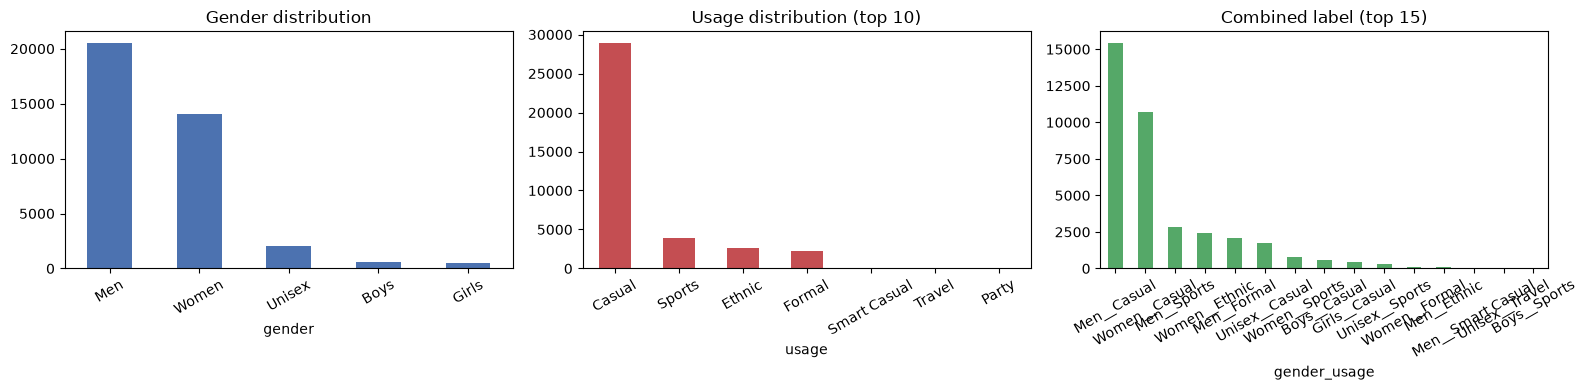

In [8]:
# Drop rare combined classes (< 5 samples) — can't split or train on them reliably
combo_counts = df['gender_usage'].value_counts()
rare_combos  = combo_counts[combo_counts < 5].index
if len(rare_combos):
    print(f"Dropping {df['gender_usage'].isin(rare_combos).sum()} rows with rare gender_usage combinations")
    df = df[~df['gender_usage'].isin(rare_combos)].reset_index(drop=True)

# Distribution plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['gender'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Gender distribution'); axes[0].tick_params(axis='x', rotation=30)

df['usage'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Usage distribution (top 10)'); axes[1].tick_params(axis='x', rotation=30)

df['gender_usage'].value_counts().head(15).plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Combined label (top 15)'); axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 4.1 Cramér's V — are gender and usage independent?

If gender and usage were strongly associated, a combined label could exploit that joint
structure. If they are only weakly associated, a combined label buys nothing while multiplying
the number of classes. We check this quantitatively before deciding which approach to commit to.

In [9]:
from scipy.stats import chi2_contingency

def cramers_v(col_a, col_b):
    """Cramer's V -- bias-corrected, symmetric measure of association between
    two categorical variables. 0 = independent, 1 = perfectly associated."""
    confusion = pd.crosstab(col_a, col_b)
    chi2 = chi2_contingency(confusion, correction=False)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corr / min(k_corr - 1, r_corr - 1))

v_gender_usage = cramers_v(df['gender'], df['usage'])
print(f"Cramer's V (gender vs usage): {v_gender_usage:.3f}")

# Sparsity of the combined label space
combo_counts = df['gender_usage'].value_counts()
n_combos     = len(combo_counts)
n_sparse     = (combo_counts < 10).sum()
n_possible   = df['gender'].nunique() * df['usage'].nunique()

print(f"\nCombined label space: {n_combos} observed combinations out of "
      f"{n_possible} theoretically possible "
      f"({df['gender'].nunique()} genders x {df['usage'].nunique()} usages)")
print(f"{n_sparse}/{n_combos} observed combinations have fewer than 10 samples")

Cramer's V (gender vs usage): 0.205

Combined label space: 19 observed combinations out of 35 theoretically possible (5 genders x 7 usages)
1/19 observed combinations have fewer than 10 samples


### 4.2 Decision: treat gender and usage as two separate targets

Based on the analysis above, this notebook uses **two separate classifiers** rather than one
combined `gender__usage` class. Reasoning:

1. **Class explosion / sparsity.** The combined label space has far more classes than either
   target alone, and a large share of the observed combinations have very few samples (printed
   above). Sparse classes are hard to learn and unreliable to evaluate.
2. **Weak association.** The Cramér's V score above is well below 1 — gender and usage are
   largely independent signals, so modelling their joint distribution buys little while the
   class count multiplies.
3. **Independent error analysis.** Separate models give a clean confusion matrix per target, so
   we can tell whether a mistake is a *gender* mistake or a *usage* mistake — impossible with one
   joint label.
4. **Deployment realism.** In a real catalogue/search system, "filter by Women" and "filter by
   Formal" are independent filters a user can apply on their own — separate models mirror that
   use case.
5. **Empirical confirmation (Section 12).** Approach B (combined label) and Approach C (dual-head)
   are still trained and evaluated as comparison baselines. Both underperform the separate
   classifiers (Approach A) on validation Macro-F1 — the strongest evidence that the
   separate-target decision was correct for this dataset.

## 5. Label encoding

In [10]:
gender_enc       = LabelEncoder()
usage_enc        = LabelEncoder()
gender_usage_enc = LabelEncoder()

df['gender_label']       = gender_enc.fit_transform(df['gender'])
df['usage_label']        = usage_enc.fit_transform(df['usage'])
df['gender_usage_label'] = gender_usage_enc.fit_transform(df['gender_usage'])

N_GENDER       = len(gender_enc.classes_)
N_USAGE        = len(usage_enc.classes_)
N_COMBINED     = len(gender_usage_enc.classes_)

print(f"Gender classes ({N_GENDER}):        {list(gender_enc.classes_)}")
print(f"Usage classes ({N_USAGE}):          {list(usage_enc.classes_)}")
print(f"Combined classes ({N_COMBINED}):    {list(gender_usage_enc.classes_)[:8]} ...")

Gender classes (5):        ['Boys', 'Girls', 'Men', 'Unisex', 'Women']
Usage classes (7):          ['Casual', 'Ethnic', 'Formal', 'Party', 'Smart Casual', 'Sports', 'Travel']
Combined classes (19):    ['Boys__Casual', 'Boys__Ethnic', 'Boys__Sports', 'Girls__Casual', 'Girls__Ethnic', 'Men__Casual', 'Men__Ethnic', 'Men__Formal'] ...


## 6. Train / Validation split
*(Same leak-free strategy as Tasks 1 & 2: StratifiedGroupKFold on masterCategory)*

In [11]:
# MODIFY: the split is loaded, not recomputed. It used to be a fresh StratifiedGroupKFold
# draw on masterCategory, which produced different train/val membership from Tasks 1 and 2 --
# so a Task 3 model was scored on rows another task had trained on, and the pipeline notebook
# could not compare the four tasks on one validation set. Membership now comes from
# train_full.csv / val_full.csv; the leak-free property is unchanged, it is just inherited
# from the preprocessing notebook (stratified composite key, grouped on dup_group).
train_data = df[df['id'].isin(TRAIN_IDS)].reset_index(drop=True)
val_data   = df[df['id'].isin(VAL_IDS)].reset_index(drop=True)

print(f"Train: {len(train_data)}, Val: {len(val_data)}")
overlap = set(train_data['dup_group']) & set(val_data['dup_group'])
print(f"Duplicate groups in both splits: {len(overlap)} (should be 0)")

assert len(train_data) + len(val_data) == len(df), "rows lost when re-deriving the split"
assert not (set(train_data['id']) & set(val_data['id'])), "id overlap between train and val"
assert len(train_data) and len(val_data), "one side of the split is empty -- check SUBSET_SIZE"

Train: 28311, Val: 9439
Duplicate groups in both splits: 0 (should be 0)


## 7. Metadata features
*(Same one-hot pipeline as Task 2 — reused directly)*

In [12]:
from sklearn.preprocessing import OneHotEncoder

# Task 3 metadata: exclude gender and usage (they are the targets — leakage if included)
# Also exclude season (it was Task 2's target — still useful here as a feature)
META_COLS = ['masterCategory', 'subCategory', 'articleType', 'baseColour', 'year', 'season']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
meta_train = ohe.fit_transform(train_data[META_COLS])
meta_val   = ohe.transform(val_data[META_COLS])
META_DIM   = meta_train.shape[1]

print(f"Metadata feature dimension: {META_DIM}")

joblib.dump(ohe, OUTPUT_DIR / 'ohe_metadata.joblib')
joblib.dump(gender_enc,       OUTPUT_DIR / 'gender_encoder.joblib')
joblib.dump(usage_enc,        OUTPUT_DIR / 'usage_encoder.joblib')
joblib.dump(gender_usage_enc, OUTPUT_DIR / 'gender_usage_encoder.joblib')
print("Encoders saved.")

Metadata feature dimension: 228
Encoders saved.


## 8. Shared utilities
*(Reused verbatim from Task 2)*

In [13]:
# ── Image transforms ──────────────────────────────────────────────────────────
# MODIFY: normalisation constants now come from pipeline_config.json (this dataset's own
# per-channel mean/std) instead of the ImageNet constants. The pipeline notebook rebuilds
# its transforms from that same config and uses them to run these models, so training and
# chained inference must agree -- with ImageNet stats here the pipeline would feed these
# models differently-scaled pixels than they were trained on. H, W also now follow the
# config, which fixes the (60, 80) / (80, 60) swap between TESTING and REAL mode.
H, W = IMG_SIZE

train_transform = T.Compose([
    T.Resize((H, W)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(NORM_MEAN, NORM_STD),
])

eval_transform = T.Compose([
    T.Resize((H, W)),
    T.ToTensor(),
    T.Normalize(NORM_MEAN, NORM_STD),
])


# ── Weighted sampler for class imbalance ──────────────────────────────────────
def get_weighted_sampler(frame, label_col):
    counts  = frame[label_col].value_counts().to_dict()
    weights = frame[label_col].map(lambda c: 1.0 / counts[c]).values.copy()
    return WeightedRandomSampler(weights, len(weights), replacement=True)


# ── Dataset classes ───────────────────────────────────────────────────────────
class FashionImageDataset(Dataset):
    """Image-only dataset for single-label tasks."""
    def __init__(self, frame, image_dir, label_col, transform):
        self.frame     = frame.reset_index(drop=True)
        self.image_dir = image_dir
        self.label_col = label_col
        self.transform = transform

    def __len__(self): return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        with Image.open(self.image_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im.convert('RGB'))
        return img, torch.tensor(row[self.label_col], dtype=torch.long)


class MultiInputDataset(Dataset):
    """Image + metadata dataset for single-label tasks."""
    def __init__(self, frame, metadata, labels, image_dir, transform):
        self.frame     = frame.reset_index(drop=True)
        self.metadata  = metadata
        self.labels    = labels
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self): return len(self.frame)

    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            img = self.transform(im.convert('RGB'))
        meta = torch.tensor(self.metadata[i], dtype=torch.float32)
        lbl  = torch.tensor(self.labels[i],   dtype=torch.long)
        return img, meta, lbl


class DualLabelDataset(Dataset):
    """Image + metadata dataset that returns TWO labels (gender, usage).
    Used by the dual-head model."""
    def __init__(self, frame, metadata, gender_labels, usage_labels, image_dir, transform):
        self.frame         = frame.reset_index(drop=True)
        self.metadata      = metadata
        self.gender_labels = gender_labels
        self.usage_labels  = usage_labels
        self.image_dir     = image_dir
        self.transform     = transform

    def __len__(self): return len(self.frame)

    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            img = self.transform(im.convert('RGB'))
        meta   = torch.tensor(self.metadata[i],      dtype=torch.float32)
        g_lbl  = torch.tensor(self.gender_labels[i], dtype=torch.long)
        u_lbl  = torch.tensor(self.usage_labels[i],  dtype=torch.long)
        return img, meta, g_lbl, u_lbl

In [14]:
# ── Model building blocks (reused from Task 2) ────────────────────────────────

class ConvBlock(nn.Module):
    """Residual Conv Block with SiLU and BatchNorm."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.act   = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch))
            if in_ch != out_ch else nn.Sequential()
        )
    def forward(self, x):
        return self.act(self.bn2(self.conv2(self.act(self.bn1(self.conv1(x))))) + self.shortcut(x))


class ImprovedSmallImageEncoder(nn.Module):
    """Upgraded small CNN with residual connections (from Task 2)."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.stage1 = ConvBlock(3, 32);   self.pool1 = nn.MaxPool2d(2)
        self.stage2 = ConvBlock(32, 64);  self.pool2 = nn.MaxPool2d(2)
        self.stage3 = ConvBlock(64, 128); self.pool3 = nn.MaxPool2d(2)
        self.stage4 = ConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim), nn.SiLU()
        )
    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        return self.proj(self.global_pool(self.stage4(x)).flatten(1))


class PretrainedResNet18Encoder(nn.Module):
    """ImageNet-pretrained ResNet18 as a feature extractor."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim  = out_dim
        self.proj     = nn.Linear(512, out_dim)
    def forward(self, x):
        return self.proj(self.backbone(x))


class MultiInputNet(nn.Module):
    """Image encoder + metadata MLP → single classification head."""
    def __init__(self, metadata_dim, n_classes, image_encoder):
        super().__init__()
        self.image = image_encoder
        self.meta  = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128), nn.ReLU(), nn.Dropout(0.2)
        )
        self.head = nn.Sequential(
            nn.Linear(image_encoder.out_dim + 128, 256),
            nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, n_classes)
        )
    def forward(self, image, metadata):
        return self.head(torch.cat([self.image(image), self.meta(metadata)], dim=1))


class GatedFusionNet(nn.Module):
    """Image encoder + metadata MLP, fused with a *gate* instead of a plain
    concatenation. A small gate network looks at both modalities and learns,
    per-sample, how much to trust the image branch vs. the metadata branch:
        gate  = sigmoid(W [image_feat ; meta_feat])
        fused = gate * image_feat + (1 - gate) * meta_feat
    This is the second fusion strategy investigated alongside the plain
    concatenation used by MultiInputNet above -- it lets the model down-weight
    one modality per-sample instead of always trusting both equally."""
    def __init__(self, metadata_dim, n_classes, image_encoder, fusion_dim=128):
        super().__init__()
        self.image = image_encoder
        self.meta  = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, fusion_dim), nn.ReLU(), nn.Dropout(0.2)
        )
        self.image_proj = nn.Linear(image_encoder.out_dim, fusion_dim)
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim), nn.Sigmoid()
        )
        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, n_classes)
        )

    def forward(self, image, metadata):
        img_feat  = self.image_proj(self.image(image))
        meta_feat = self.meta(metadata)
        g = self.gate(torch.cat([img_feat, meta_feat], dim=1))
        fused = g * img_feat + (1 - g) * meta_feat
        return self.head(fused)


# ── NEW for Task 3: Dual-head model ───────────────────────────────────────────
class DualHeadNet(nn.Module):
    """Shared image+metadata backbone with two separate classification heads:
    one for gender, one for usage. Jointly trained with a weighted sum of losses."""
    def __init__(self, metadata_dim, n_gender, n_usage, image_encoder):
        super().__init__()
        self.image = image_encoder
        self.meta  = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128), nn.ReLU(), nn.Dropout(0.2)
        )
        fused_dim = image_encoder.out_dim + 128
        self.shared = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.ReLU(), nn.Dropout(0.3)
        )
        self.gender_head = nn.Linear(256, n_gender)
        self.usage_head  = nn.Linear(256, n_usage)

    def forward(self, image, metadata):
        fused  = torch.cat([self.image(image), self.meta(metadata)], dim=1)
        shared = self.shared(fused)
        return self.gender_head(shared), self.usage_head(shared)

In [15]:
# ── Training utilities (reused from Task 2) ───────────────────────────────────

class EarlyStopping:
    def __init__(self, patience=5, delta=0, mode='min'):
        assert mode in ('max', 'min')
        self.patience = patience; self.delta = delta; self.mode = mode
        self.best_score = None; self.early_stop = False
        self.counter = 0; self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model


def to_device(batch):
    """Move all tensors in batch to DEVICE; last tensor is always the label(s)."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()
    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss   = criterion(logits, labels)
            if train_mode:
                optimiser.zero_grad(); loss.backward(); optimiser.step()
            running_loss += loss.item() * labels.size(0)
            n += labels.size(0)
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())
    return running_loss / n, f1_score(actual, preds, average='macro', zero_division=0)


def fit(model, loader_tr, loader_va, model_name='model', patience=PATIENCE, lr=LR):
    criterion    = nn.CrossEntropyLoss()
    optimiser    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler    = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    stopper      = EarlyStopping(patience=patience, mode='min')
    history      = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    # FIX: also track train F1 AT the best (early-stopping-selected) epoch, not
    # just val F1 — needed to plot train vs val F1 side by side later.
    best_val_f1  = None; best_train_f1 = None; best_epoch = None

    for epoch in range(EPOCHS):
        tag = f'{model_name} {epoch+1}/{EPOCHS}'
        tr_loss, tr_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        va_loss, va_f1 = run_epoch(model, loader_va, criterion, None,      desc=f'{tag} val')
        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['train_f1'].append(tr_f1);    history['val_f1'].append(va_f1)
        current_lr = optimiser.param_groups[0]['lr']
        print(f'Epoch {epoch+1}/{EPOCHS} — tr_loss={tr_loss:.4f}  va_loss={va_loss:.4f}  '
              f'tr_f1={tr_f1:.4f}  va_f1={va_f1:.4f}  lr={current_lr:.2e}')
        scheduler.step(va_loss)
        stopper(va_loss, model)
        if stopper.counter == 0:
            best_val_f1 = va_f1; best_train_f1 = tr_f1; best_epoch = epoch + 1
        if stopper.early_stop:
            print(f'Early stopping at epoch {epoch+1} (best epoch={best_epoch})')
            break

    model = stopper.load_best_model(model)
    plot_training_curves(history, model_name)
    print(f'>>> {model_name}: best epoch={best_epoch}, train_f1={best_train_f1:.4f}, val_f1={best_val_f1:.4f}')
    return model, best_val_f1, best_train_f1, best_epoch


def evaluate(model, loader, label_col='single'):
    model.eval(); preds, actual = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            preds.extend(model(*inputs).argmax(1).cpu().numpy())
            actual.extend(labels.cpu().numpy())
    return f1_score(actual, preds, average='macro', zero_division=0)


def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train'); axes[1].plot(history['val_f1'], label='Val')
    axes[1].set_title('Macro-F1'); axes[1].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()


## 9. Approach A — Two separate classifiers (gender | usage)

Train one model for each target independently. Simpler, but ignores the correlation between gender and usage.

**Section order:** 9.1 sets the metadata-only floor, 9.2 immediately follows up with an
image-only comparison (no metadata at all) so the two single-modality extremes are established
before anything fuses them; 9.3–9.6 are the image+metadata MultiInput models; 9.7–9.8 explore
extra fusion/ensembling strategies on top of those.

In [16]:
# ── Labels ────────────────────────────────────────────────────────────────────
y_gender_train = train_data['gender_label'].values
y_gender_val   = val_data['gender_label'].values
y_usage_train  = train_data['usage_label'].values
y_usage_val    = val_data['usage_label'].values

# ── Weighted samplers ─────────────────────────────────────────────────────────
sampler_gender = get_weighted_sampler(train_data, 'gender_label')
sampler_usage  = get_weighted_sampler(train_data, 'usage_label')

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ── Feature ablation: which metadata columns actually matter for gender/usage? ──
# Same idea as Task 2's ablation, run separately per Task 3 target since gender
# and usage are independent classification problems with possibly different
# feature dependencies.
FEATURE_GROUPS_T3 = {col: [col] for col in META_COLS}   # META_COLS from Section 9.1
CAT_COLS_T3 = ['masterCategory', 'subCategory', 'articleType', 'baseColour', 'season']
NUM_COLS_T3 = ['year']


def run_rf_ablation_t3(name, train_matrix, val_matrix, y_tr, y_va):
    model = RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(train_matrix, y_tr)
    train_f1 = f1_score(y_tr, model.predict(train_matrix), average='macro', zero_division=0)
    val_f1 = f1_score(y_va, model.predict(val_matrix), average='macro', zero_division=0)
    print(f'{name:32s} train F1: {train_f1:.4f}  val F1: {val_f1:.4f}')
    return train_f1, val_f1


def build_metadata_matrix_groups_t3(train_df, val_df, active_groups):
    """Builds a design matrix using only the given META_COLS groups."""
    cat_features = [c for c in active_groups if c in CAT_COLS_T3]
    num_features = [c for c in active_groups if c in NUM_COLS_T3]

    transformers = []
    if cat_features:
        transformers.append(('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features))
    if num_features:
        transformers.append(('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), num_features))
    if not transformers:
        raise ValueError("At least one feature group must be selected.")

    preprocessor = ColumnTransformer(transformers)
    cols = cat_features + num_features
    Xtr = train_df[cols].copy()
    Xva = val_df[cols].copy()
    for c in cat_features:
        Xtr[c] = Xtr[c].astype(object)
        Xva[c] = Xva[c].astype(object)
    for c in num_features:
        Xtr[c] = pd.to_numeric(Xtr[c], errors='coerce')
        Xva[c] = pd.to_numeric(Xva[c], errors='coerce')

    Mtr = preprocessor.fit_transform(Xtr)
    Mva = preprocessor.transform(Xva)
    Mtr = Mtr.toarray() if hasattr(Mtr, 'toarray') else Mtr
    Mva = Mva.toarray() if hasattr(Mva, 'toarray') else Mva
    return Mtr.astype('float32'), Mva.astype('float32')


all_groups_t3 = list(FEATURE_GROUPS_T3.keys())

for target_name, y_tr, y_va in [('gender', y_gender_train, y_gender_val),
                                 ('usage',  y_usage_train,  y_usage_val)]:
    print(f"\n=== Ablation for target: {target_name} ===")
    ablation_results = {}

    m_tr, m_va = build_metadata_matrix_groups_t3(train_data, val_data, active_groups=all_groups_t3)
    ablation_results['Full Model (Baseline)'] = run_rf_ablation_t3(
        'Full Model (Baseline)', m_tr, m_va, y_tr, y_va)

    for group_to_drop in all_groups_t3:
        remaining = [g for g in all_groups_t3 if g != group_to_drop]
        m_tr, m_va = build_metadata_matrix_groups_t3(train_data, val_data, active_groups=remaining)
        label = f'Without {group_to_drop}'
        ablation_results[label] = run_rf_ablation_t3(label, m_tr, m_va, y_tr, y_va)

    ablation_df = pd.DataFrame(ablation_results, index=['Train F1', 'Validation F1']).T
    display(ablation_df.round(4))

In [ ]:
META_COLS = ['masterCategory', 'subCategory', 'articleType', 'year', 'season']  # dropped baseColour
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
meta_train = ohe.fit_transform(train_data[META_COLS])
meta_val   = ohe.transform(val_data[META_COLS])
META_DIM   = meta_train.shape[1]

In [17]:
# ─── 9.1 Baseline: Logistic Regression on metadata only ──────────────────────
BASELINE_DIR = OUTPUT_DIR / 'baselines'
BASELINE_DIR.mkdir(exist_ok=True)

logreg_gender = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg_gender.fit(meta_train, y_gender_train)
logreg_gender_train_f1 = f1_score(y_gender_train, logreg_gender.predict(meta_train), average='macro', zero_division=0)
logreg_gender_f1       = f1_score(y_gender_val,   logreg_gender.predict(meta_val),   average='macro', zero_division=0)

logreg_usage = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg_usage.fit(meta_train, y_usage_train)
logreg_usage_train_f1 = f1_score(y_usage_train, logreg_usage.predict(meta_train), average='macro', zero_division=0)
logreg_usage_f1       = f1_score(y_usage_val,   logreg_usage.predict(meta_val),   average='macro', zero_division=0)

print(f'Logistic Regression — gender train F1: {logreg_gender_train_f1:.4f}  val F1: {logreg_gender_f1:.4f}')
print(f'Logistic Regression — usage  train F1: {logreg_usage_train_f1:.4f}  val F1: {logreg_usage_f1:.4f}')

print('\nGender classification report (val):')
print(classification_report(y_gender_val, logreg_gender.predict(meta_val),
                             target_names=gender_enc.classes_, zero_division=0))
print('\nUsage classification report (val):')
print(classification_report(y_usage_val, logreg_usage.predict(meta_val),
                             target_names=usage_enc.classes_, zero_division=0))

joblib.dump(logreg_gender, BASELINE_DIR / 'logreg_gender.joblib')
joblib.dump(logreg_usage,  BASELINE_DIR / 'logreg_usage.joblib')


Logistic Regression — gender train F1: 0.4394  val F1: 0.4415
Logistic Regression — usage  train F1: 0.4153  val F1: 0.4032

Gender classification report (val):
              precision    recall  f1-score   support

        Boys       0.08      0.77      0.14       143
       Girls       0.13      0.69      0.22       126
         Men       0.85      0.59      0.70      5092
      Unisex       0.30      0.76      0.43       552
       Women       0.89      0.61      0.72      3526

    accuracy                           0.61      9439
   macro avg       0.45      0.68      0.44      9439
weighted avg       0.81      0.61      0.67      9439


Usage classification report (val):
              precision    recall  f1-score   support

      Casual       0.97      0.58      0.73      7254
      Ethnic       0.81      0.95      0.87       611
      Formal       0.40      0.90      0.55       564
       Party       0.01      0.75      0.03         4
Smart Casual       0.01      0.42      0.01

['../outputs/task3_models/baselines/logreg_usage.joblib']

### 9.2 Image-only model comparison — pick & save the best model per label

Everything trained so far in Approach A fuses image **and** metadata (`MultiInputNet` /
`GatedFusionNet`). To know how much the metadata branch is actually contributing, and to have a
pure-vision model available (e.g. for a scenario where no metadata is available at inference
time — just a product photo), this section trains **image-only** classifiers for `gender` and
`usage` and compares them head-to-head.

Six encoders are compared, reusing the encoder classes from Section 8 plus three new ones defined
below:

| Encoder | From scratch? | Role |
|---|---|---|
| `SmallImageEncoder` (plain CNN, no residual/attention) | ✅ Yes | Candidate for best-model selection |
| `ImprovedSmallImageEncoder` (residual CNN) | ✅ Yes | Candidate for best-model selection |
| `SEResidualImageEncoder` (residual CNN + Squeeze-Excitation) | ✅ Yes | Candidate for best-model selection |
| `ScratchResNet18Encoder` (ResNet18 architecture, random init) | ✅ Yes | Candidate for best-model selection |
| `PretrainedResNet18Encoder` | ❌ ImageNet-pretrained | Comparison only |
| `PretrainedMobileNetV3Encoder` | ❌ ImageNet-pretrained | Comparison only |

`SmallImageEncoder` is a plain conv-stack baseline with no residual connections. `SEResidualImageEncoder`
takes `ImprovedSmallImageEncoder`'s residual blocks and adds a Squeeze-and-Excitation gate to each one,
so the network can learn to reweight feature channels per-sample instead of treating them all equally.
`ScratchResNet18Encoder` reuses the standard ResNet18 architecture (via `resnet18(weights=None)`) but
with randomly-initialised weights, so it is a legitimate from-scratch candidate — unlike
`PretrainedResNet18Encoder`, which loads ImageNet weights and is comparison-only under the
assignment's "train your own model" rule (already applied to the multi-input ResNet18 runs in
9.4/9.6). The two ImageNet-pretrained backbones are shown for comparison but are **not eligible**
to be selected as the final image-only model — only the four from-scratch candidates can win the
selection below. The best **eligible** model is then saved separately for `gender` and for `usage`.

In [18]:
# ── Image-only model + encoder ────────────────────────────────────────────────
class ImageOnlyNet(nn.Module):
    """Image encoder -> classification head, no metadata branch. Lets us
    measure how much signal the image alone carries for each target."""
    def __init__(self, n_classes, image_encoder, dropout=0.3):
        super().__init__()
        self.image = image_encoder
        self.head = nn.Sequential(
            nn.Linear(image_encoder.out_dim, 256), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(256, n_classes)
        )
    def forward(self, image):
        return self.head(self.image(image))


class SmallImageEncoder(nn.Module):
    """Plain small CNN -- no residual connections, no attention. The
    'vanilla' baseline architecture that ImprovedSmallImageEncoder and
    SEResidualImageEncoder are compared against."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        x = self.features(x)
        return self.proj(self.global_pool(x).flatten(1))


class SEBlock(nn.Module):
    """Squeeze-and-Excitation block: pools global context per channel, then
    learns a per-channel gate so the network can emphasise the most
    informative feature channels for each sample."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced), nn.ReLU(inplace=True),
            nn.Linear(reduced, channels), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        gate = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        return x * gate


class SEConvBlock(nn.Module):
    """Residual ConvBlock (as in Section 8) with a Squeeze-and-Excitation
    gate applied to its output before the skip connection."""
    def __init__(self, in_ch, out_ch, reduction=16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.act   = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.se    = SEBlock(out_ch, reduction=reduction)
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch))
            if in_ch != out_ch else nn.Sequential()
        )
    def forward(self, x):
        out = self.bn2(self.conv2(self.act(self.bn1(self.conv1(x)))))
        out = self.se(out)
        return self.act(out + self.shortcut(x))


class SEResidualImageEncoder(nn.Module):
    """Same stage layout as ImprovedSmallImageEncoder, but every block is an
    SEConvBlock -- residual connections plus a per-channel attention gate."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.stage1 = SEConvBlock(3, 32);   self.pool1 = nn.MaxPool2d(2)
        self.stage2 = SEConvBlock(32, 64);  self.pool2 = nn.MaxPool2d(2)
        self.stage3 = SEConvBlock(64, 128); self.pool3 = nn.MaxPool2d(2)
        self.stage4 = SEConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim), nn.SiLU()
        )
    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        return self.proj(self.global_pool(self.stage4(x)).flatten(1))


class ScratchResNet18Encoder(nn.Module):
    """Same ResNet18 architecture as PretrainedResNet18Encoder, but with
    randomly-initialised weights (weights=None) — a legitimate from-scratch
    candidate, unlike its ImageNet-pretrained counterpart."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim  = out_dim
        self.proj     = nn.Linear(512, out_dim)
    def forward(self, x):
        return self.proj(self.backbone(x))


class PretrainedMobileNetV3Encoder(nn.Module):
    """ImageNet-pretrained MobileNetV3-Small as a feature extractor —
    comparison only (pretrained), same role as PretrainedResNet18Encoder."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        backbone.classifier = nn.Identity()   # drop the ImageNet head, keep 576-d features
        self.backbone = backbone
        self.out_dim  = out_dim
        self.proj     = nn.Linear(576, out_dim)
    def forward(self, x):
        return self.proj(self.backbone(x))


In [19]:
# ── Image-only datasets & loaders ─────────────────────────────────────────────
# Reuses FashionImageDataset (defined in Section 8) and the class-balanced
# samplers already built above (shared across Approach A).
train_ds_gender_imgonly = FashionImageDataset(train_data, IMAGES_TRAIN_DIR, 'gender_label', train_transform)
val_ds_gender_imgonly   = FashionImageDataset(val_data,   IMAGES_TRAIN_DIR, 'gender_label', eval_transform)
train_ds_usage_imgonly  = FashionImageDataset(train_data, IMAGES_TRAIN_DIR, 'usage_label',  train_transform)
val_ds_usage_imgonly    = FashionImageDataset(val_data,   IMAGES_TRAIN_DIR, 'usage_label',  eval_transform)

train_loader_gender_imgonly = DataLoader(train_ds_gender_imgonly, batch_size=BATCH_SIZE, sampler=sampler_gender,
                                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_gender_imgonly   = DataLoader(val_ds_gender_imgonly,   batch_size=BATCH_SIZE, shuffle=False,
                                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
train_loader_usage_imgonly  = DataLoader(train_ds_usage_imgonly,  batch_size=BATCH_SIZE, sampler=sampler_usage,
                                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_usage_imgonly    = DataLoader(val_ds_usage_imgonly,    batch_size=BATCH_SIZE, shuffle=False,
                                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))


ImageOnly-SmallCNN (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.9926  va_loss=0.9458  tr_f1=0.5891  va_f1=0.4535  lr=3.00e-04


ImageOnly-SmallCNN (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (gender) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

ImageOnly-SmallCNN (gender) 23/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/50 — tr_loss=0.1503  va_loss=0.4050  tr_f1=0.9469  va_f1=0.7323  lr=1.87e-05


ImageOnly-SmallCNN (gender) 24/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (gender) 24/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/50 — tr_loss=0.1411  va_loss=0.4133  tr_f1=0.9500  va_f1=0.7280  lr=9.37e-06
Early stopping at epoch 24 (best epoch=14)


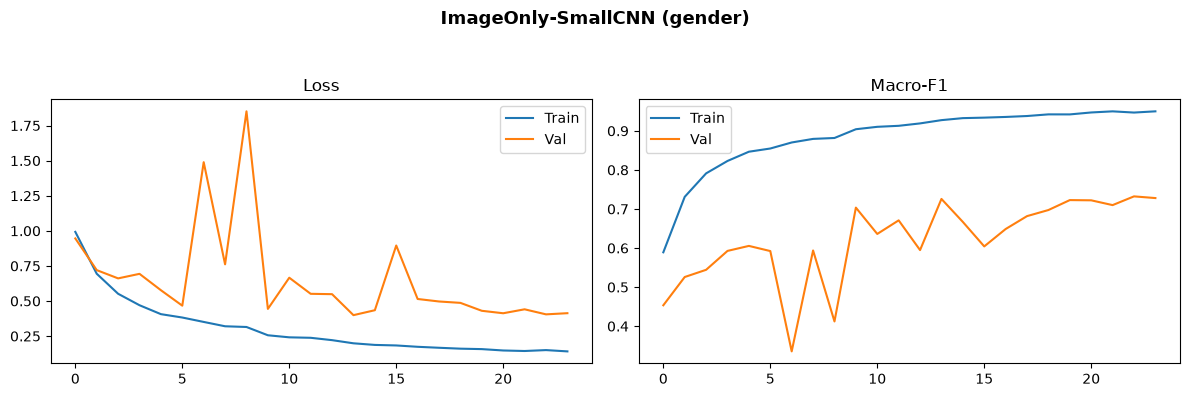

>>> ImageOnly-SmallCNN (gender): best epoch=14, train_f1=0.9275, val_f1=0.7258


ImageOnly-ImprovedSmallCNN (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ImprovedSmallCNN (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.8529  va_loss=0.5867  tr_f1=0.6625  va_f1=0.6059  lr=3.00e-04


ImageOnly-ImprovedSmallCNN (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-ImprovedSmallCNN (gender) 18/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 18/50 — tr_loss=0.0586  va_loss=0.4209  tr_f1=0.9802  va_f1=0.7687  lr=1.87e-05


ImageOnly-ImprovedSmallCNN (gender) 19/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ImprovedSmallCNN (gender) 19/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 19/50 — tr_loss=0.0513  va_loss=0.4193  tr_f1=0.9836  va_f1=0.7774  lr=9.37e-06
Early stopping at epoch 19 (best epoch=9)


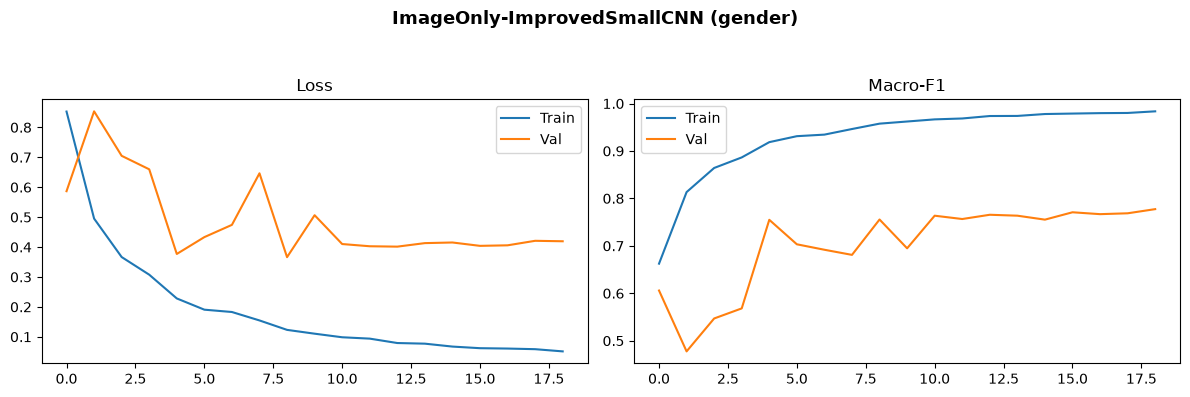

>>> ImageOnly-ImprovedSmallCNN (gender): best epoch=9, train_f1=0.9576, val_f1=0.7556


ImageOnly-SEResidualCNN (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SEResidualCNN (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.9231  va_loss=0.8371  tr_f1=0.6230  va_f1=0.4686  lr=3.00e-04


ImageOnly-SEResidualCNN (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-SEResidualCNN (gender) 21/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 21/50 — tr_loss=0.0560  va_loss=0.4154  tr_f1=0.9796  va_f1=0.7768  lr=3.75e-05


ImageOnly-SEResidualCNN (gender) 22/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SEResidualCNN (gender) 22/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 22/50 — tr_loss=0.0523  va_loss=0.4107  tr_f1=0.9815  va_f1=0.7765  lr=1.87e-05
Early stopping at epoch 22 (best epoch=12)


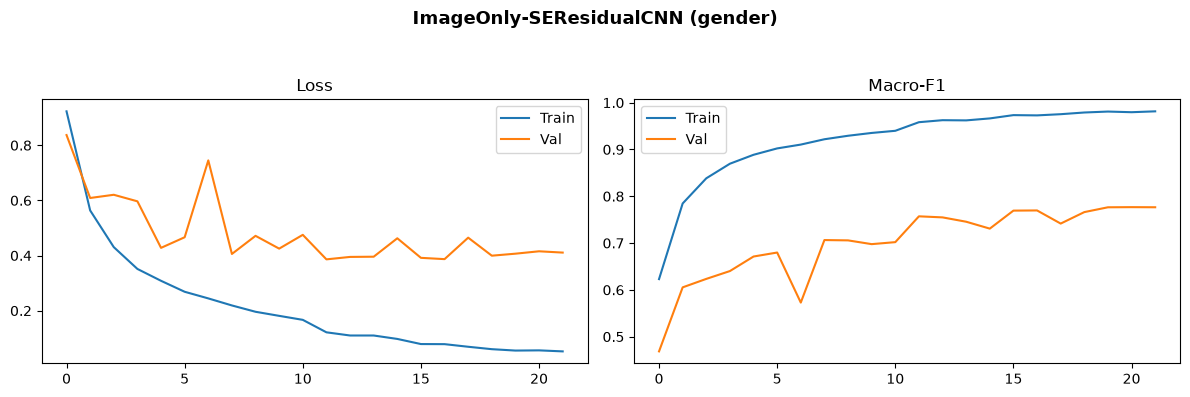

>>> ImageOnly-SEResidualCNN (gender): best epoch=12, train_f1=0.9583, val_f1=0.7571


ImageOnly-ResNet18FromScratch (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18FromScratch (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.6347  va_loss=0.6408  tr_f1=0.7586  va_f1=0.6280  lr=3.00e-04


ImageOnly-ResNet18FromScratch (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-ResNet18FromScratch (gender) 19/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 19/50 — tr_loss=0.0380  va_loss=0.5201  tr_f1=0.9878  va_f1=0.7457  lr=7.50e-05


ImageOnly-ResNet18FromScratch (gender) 20/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18FromScratch (gender) 20/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 20/50 — tr_loss=0.0279  va_loss=0.5345  tr_f1=0.9908  va_f1=0.7423  lr=3.75e-05
Early stopping at epoch 20 (best epoch=10)


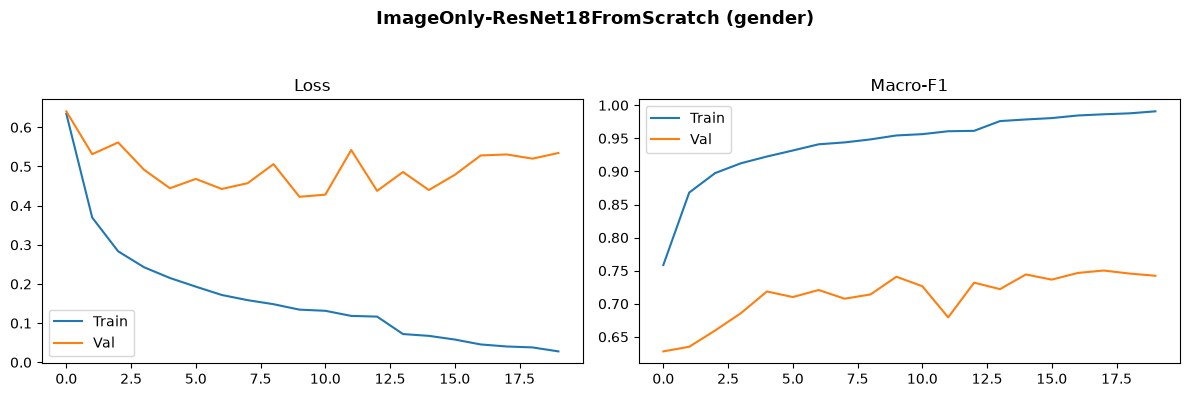

>>> ImageOnly-ResNet18FromScratch (gender): best epoch=10, train_f1=0.9544, val_f1=0.7409
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 75.5MB/s]


ImageOnly-ResNet18Pretrained (gender) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18Pretrained (gender) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.4706  va_loss=0.5159  tr_f1=0.8247  va_f1=0.6962  lr=3.00e-04


...

ImageOnly-ResNet18Pretrained (gender) [comparison only] 16/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 16/50 — tr_loss=0.0190  va_loss=0.4131  tr_f1=0.9943  va_f1=0.8069  lr=3.75e-05


ImageOnly-ResNet18Pretrained (gender) [comparison only] 17/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18Pretrained (gender) [comparison only] 17/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 17/50 — tr_loss=0.0196  va_loss=0.4113  tr_f1=0.9944  va_f1=0.8031  lr=1.87e-05
Early stopping at epoch 17 (best epoch=7)


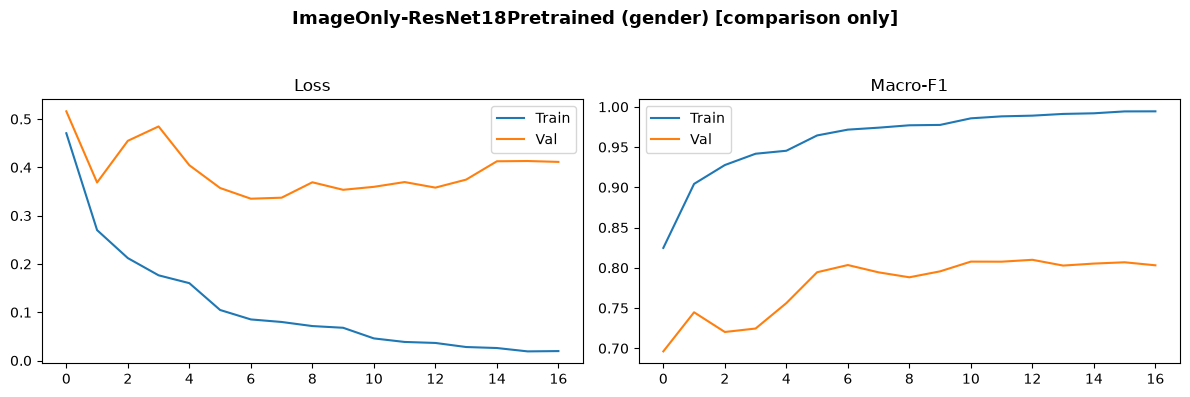

>>> ImageOnly-ResNet18Pretrained (gender) [comparison only]: best epoch=7, train_f1=0.9717, val_f1=0.8034
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 45.2MB/s]


ImageOnly-MobileNetV3Pretrained (gender) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-MobileNetV3Pretrained (gender) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.6315  va_loss=0.6064  tr_f1=0.7559  va_f1=0.6266  lr=3.00e-04


...

ImageOnly-MobileNetV3Pretrained (gender) [comparison only] 20/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 20/50 — tr_loss=0.0439  va_loss=0.4692  tr_f1=0.9847  va_f1=0.7838  lr=3.75e-05


ImageOnly-MobileNetV3Pretrained (gender) [comparison only] 21/50 train:   0%|          | 0/443 [00:00<?, ?it/s…

ImageOnly-MobileNetV3Pretrained (gender) [comparison only] 21/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 21/50 — tr_loss=0.0439  va_loss=0.4701  tr_f1=0.9851  va_f1=0.7845  lr=1.87e-05
Early stopping at epoch 21 (best epoch=11)


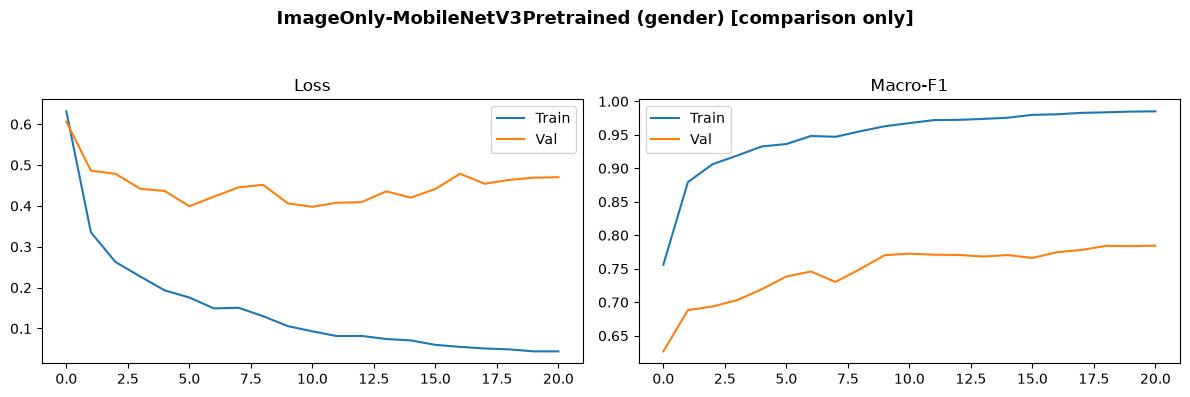

>>> ImageOnly-MobileNetV3Pretrained (gender) [comparison only]: best epoch=11, train_f1=0.9675, val_f1=0.7725


In [20]:
# ─── 9.2.1 GENDER — train all six image-only candidates ──────────────────────
torch.manual_seed(RANDOM_STATE)
gender_imgonly_basiccnn, f1_g_img_basiccnn, tr_f1_g_img_basiccnn, _ = fit(
    ImageOnlyNet(N_GENDER, SmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-SmallCNN (gender)'
)

torch.manual_seed(RANDOM_STATE)
gender_imgonly_smallcnn, f1_g_img_smallcnn, tr_f1_g_img_smallcnn, _ = fit(
    ImageOnlyNet(N_GENDER, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-ImprovedSmallCNN (gender)'
)

torch.manual_seed(RANDOM_STATE)
gender_imgonly_seresnet, f1_g_img_seresnet, tr_f1_g_img_seresnet, _ = fit(
    ImageOnlyNet(N_GENDER, SEResidualImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-SEResidualCNN (gender)'
)

torch.manual_seed(RANDOM_STATE)
gender_imgonly_resnet18_scratch, f1_g_img_resnet18_scratch, tr_f1_g_img_resnet18_scratch, _ = fit(
    ImageOnlyNet(N_GENDER, ScratchResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-ResNet18FromScratch (gender)'
)

torch.manual_seed(RANDOM_STATE)
gender_imgonly_resnet18, f1_g_img_resnet18, tr_f1_g_img_resnet18, _ = fit(
    ImageOnlyNet(N_GENDER, PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-ResNet18Pretrained (gender) [comparison only]'
)

torch.manual_seed(RANDOM_STATE)
gender_imgonly_mobilenet, f1_g_img_mobilenet, tr_f1_g_img_mobilenet, _ = fit(
    ImageOnlyNet(N_GENDER, PretrainedMobileNetV3Encoder(out_dim=128)).to(DEVICE),
    train_loader_gender_imgonly, val_loader_gender_imgonly,
    model_name='ImageOnly-MobileNetV3Pretrained (gender) [comparison only]'
)


ImageOnly-SmallCNN (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.8264  va_loss=1.3044  tr_f1=0.6882  va_f1=0.3207  lr=3.00e-04


ImageOnly-SmallCNN (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (usage) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

ImageOnly-SmallCNN (usage) 19/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 19/50 — tr_loss=0.1320  va_loss=0.7252  tr_f1=0.9479  va_f1=0.4253  lr=3.75e-05


ImageOnly-SmallCNN (usage) 20/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SmallCNN (usage) 20/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 20/50 — tr_loss=0.1243  va_loss=0.5581  tr_f1=0.9520  va_f1=0.4591  lr=1.87e-05
Early stopping at epoch 20 (best epoch=10)


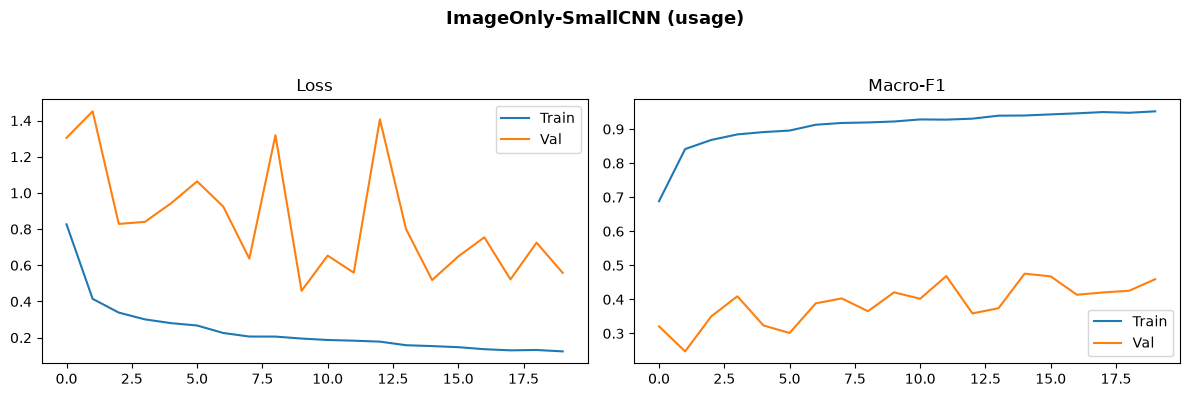

>>> ImageOnly-SmallCNN (usage): best epoch=10, train_f1=0.9222, val_f1=0.4206


ImageOnly-ImprovedSmallCNN (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ImprovedSmallCNN (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.6508  va_loss=1.4028  tr_f1=0.7605  va_f1=0.2926  lr=3.00e-04


ImageOnly-ImprovedSmallCNN (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-ImprovedSmallCNN (usage) 16/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 16/50 — tr_loss=0.0607  va_loss=0.4484  tr_f1=0.9798  va_f1=0.4511  lr=7.50e-05


ImageOnly-ImprovedSmallCNN (usage) 17/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ImprovedSmallCNN (usage) 17/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 17/50 — tr_loss=0.0513  va_loss=0.4124  tr_f1=0.9839  va_f1=0.4659  lr=3.75e-05
Early stopping at epoch 17 (best epoch=7)


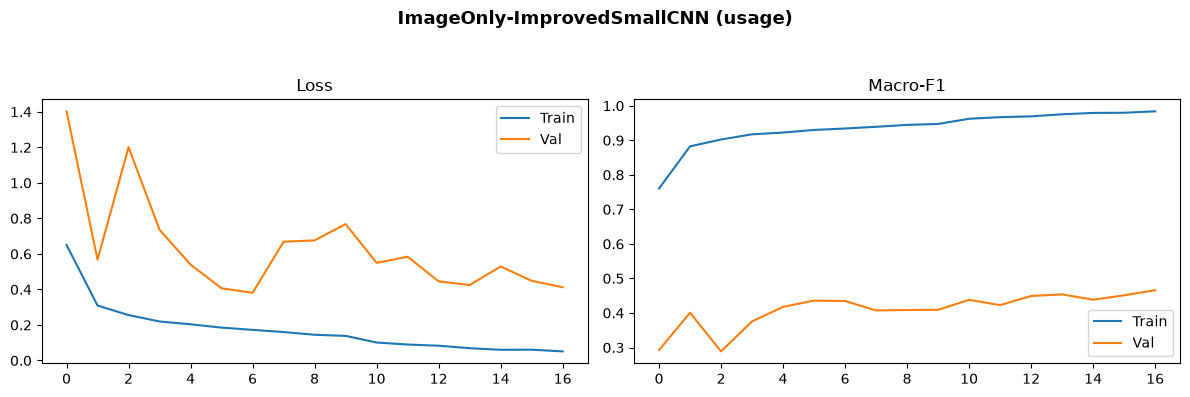

>>> ImageOnly-ImprovedSmallCNN (usage): best epoch=7, train_f1=0.9342, val_f1=0.4346


ImageOnly-SEResidualCNN (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SEResidualCNN (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.7031  va_loss=1.7705  tr_f1=0.7390  va_f1=0.2504  lr=3.00e-04


ImageOnly-SEResidualCNN (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-SEResidualCNN (usage) 20/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 20/50 — tr_loss=0.0578  va_loss=0.4396  tr_f1=0.9801  va_f1=0.5132  lr=7.50e-05


ImageOnly-SEResidualCNN (usage) 21/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-SEResidualCNN (usage) 21/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 21/50 — tr_loss=0.0491  va_loss=0.4521  tr_f1=0.9842  va_f1=0.5168  lr=3.75e-05
Early stopping at epoch 21 (best epoch=11)


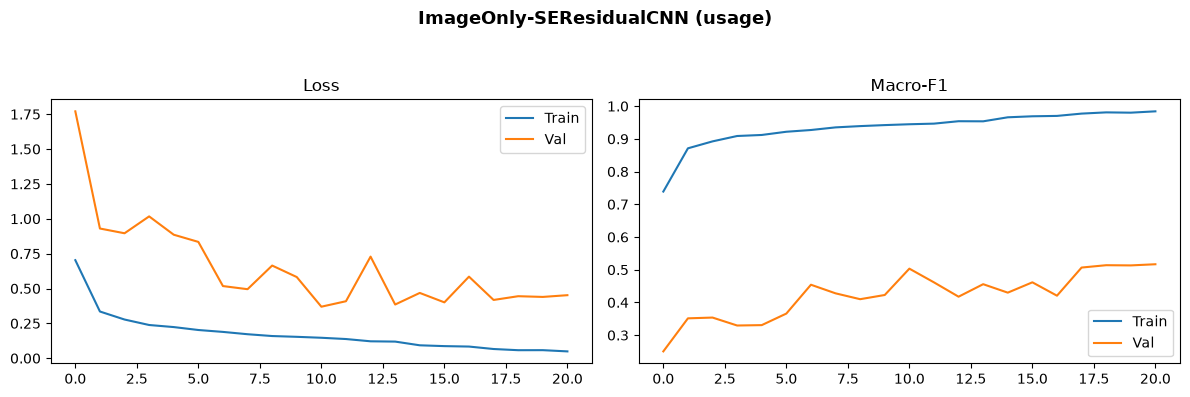

>>> ImageOnly-SEResidualCNN (usage): best epoch=11, train_f1=0.9447, val_f1=0.5033


ImageOnly-ResNet18FromScratch (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18FromScratch (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.4494  va_loss=0.5993  tr_f1=0.8363  va_f1=0.4262  lr=3.00e-04


ImageOnly-ResNet18FromScratch (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-ResNet18FromScratch (usage) 26/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 26/50 — tr_loss=0.0165  va_loss=0.6053  tr_f1=0.9951  va_f1=0.4709  lr=1.87e-05


ImageOnly-ResNet18FromScratch (usage) 27/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18FromScratch (usage) 27/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 27/50 — tr_loss=0.0164  va_loss=0.6020  tr_f1=0.9962  va_f1=0.4725  lr=9.37e-06
Early stopping at epoch 27 (best epoch=17)


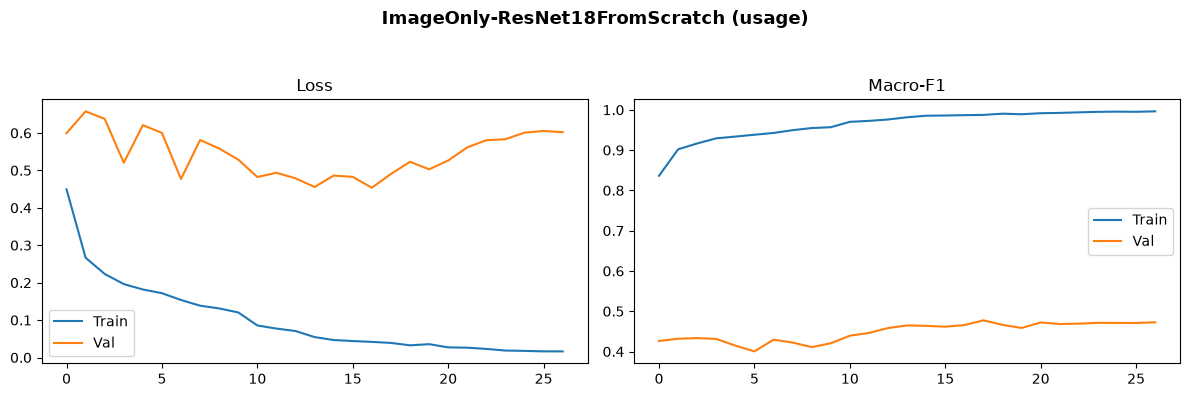

>>> ImageOnly-ResNet18FromScratch (usage): best epoch=17, train_f1=0.9867, val_f1=0.4657


ImageOnly-ResNet18Pretrained (usage) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18Pretrained (usage) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.3541  va_loss=0.5208  tr_f1=0.8770  va_f1=0.4692  lr=3.00e-04


ImageOnly-ResNet18Pretrained (usage) [comparison only] 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-ResNet18Pretrained (usage) [comparison only] 16/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 16/50 — tr_loss=0.0303  va_loss=0.3987  tr_f1=0.9905  va_f1=0.5017  lr=7.50e-05


ImageOnly-ResNet18Pretrained (usage) [comparison only] 17/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-ResNet18Pretrained (usage) [comparison only] 17/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 17/50 — tr_loss=0.0251  va_loss=0.4144  tr_f1=0.9925  va_f1=0.4897  lr=3.75e-05
Early stopping at epoch 17 (best epoch=7)


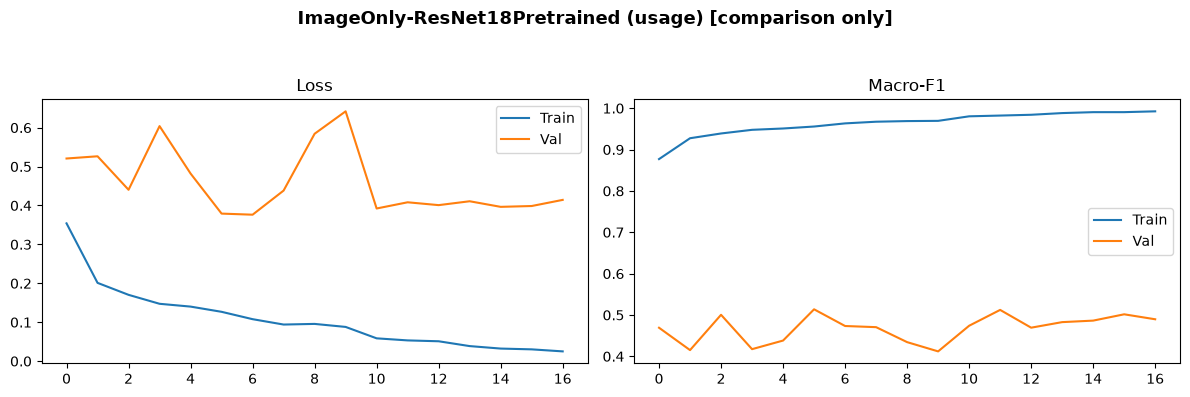

>>> ImageOnly-ResNet18Pretrained (usage) [comparison only]: best epoch=7, train_f1=0.9633, val_f1=0.4734


ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.4903  va_loss=0.7263  tr_f1=0.8185  va_f1=0.3775  lr=3.00e-04


ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 21/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 21/50 — tr_loss=0.0401  va_loss=0.4683  tr_f1=0.9874  va_f1=0.4759  lr=3.75e-05


ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 22/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

ImageOnly-MobileNetV3Pretrained (usage) [comparison only] 22/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 22/50 — tr_loss=0.0336  va_loss=0.4740  tr_f1=0.9897  va_f1=0.4763  lr=1.87e-05
Early stopping at epoch 22 (best epoch=12)


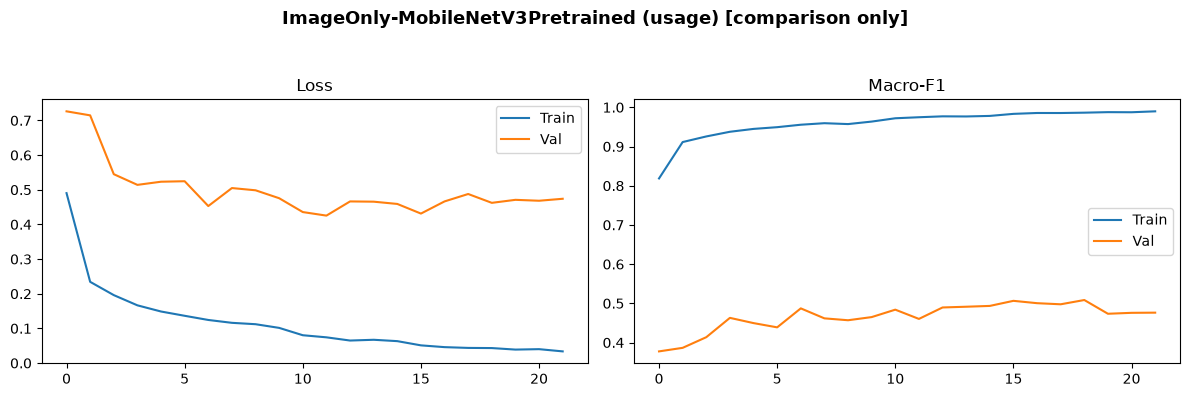

>>> ImageOnly-MobileNetV3Pretrained (usage) [comparison only]: best epoch=12, train_f1=0.9746, val_f1=0.4603


In [21]:
# ─── 9.2.2 USAGE — train all six image-only candidates ───────────────────────
torch.manual_seed(RANDOM_STATE)
usage_imgonly_basiccnn, f1_u_img_basiccnn, tr_f1_u_img_basiccnn, _ = fit(
    ImageOnlyNet(N_USAGE, SmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-SmallCNN (usage)'
)

torch.manual_seed(RANDOM_STATE)
usage_imgonly_smallcnn, f1_u_img_smallcnn, tr_f1_u_img_smallcnn, _ = fit(
    ImageOnlyNet(N_USAGE, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-ImprovedSmallCNN (usage)'
)

torch.manual_seed(RANDOM_STATE)
usage_imgonly_seresnet, f1_u_img_seresnet, tr_f1_u_img_seresnet, _ = fit(
    ImageOnlyNet(N_USAGE, SEResidualImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-SEResidualCNN (usage)'
)

torch.manual_seed(RANDOM_STATE)
usage_imgonly_resnet18_scratch, f1_u_img_resnet18_scratch, tr_f1_u_img_resnet18_scratch, _ = fit(
    ImageOnlyNet(N_USAGE, ScratchResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-ResNet18FromScratch (usage)'
)

torch.manual_seed(RANDOM_STATE)
usage_imgonly_resnet18, f1_u_img_resnet18, tr_f1_u_img_resnet18, _ = fit(
    ImageOnlyNet(N_USAGE, PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-ResNet18Pretrained (usage) [comparison only]'
)

torch.manual_seed(RANDOM_STATE)
usage_imgonly_mobilenet, f1_u_img_mobilenet, tr_f1_u_img_mobilenet, _ = fit(
    ImageOnlyNet(N_USAGE, PretrainedMobileNetV3Encoder(out_dim=128)).to(DEVICE),
    train_loader_usage_imgonly, val_loader_usage_imgonly,
    model_name='ImageOnly-MobileNetV3Pretrained (usage) [comparison only]'
)


,Label,Model,Train Macro-F1,Val Macro-F1,From scratch
0,gender,SmallCNN (from scratch),0.9275,0.7258,True
1,gender,ImprovedSmallCNN (from scratch),0.9576,0.7556,True
2,gender,SEResidualCNN (from scratch),0.9583,0.7571,True
3,gender,ResNet18 (from scratch),0.9544,0.7409,True
4,gender,"ResNet18 (pretrained, comparison only)",0.9717,0.8034,False
5,gender,"MobileNetV3-Small (pretrained, comparison only)",0.9675,0.7725,False
6,usage,SmallCNN (from scratch),0.9222,0.4206,True
7,usage,ImprovedSmallCNN (from scratch),0.9342,0.4346,True
8,usage,SEResidualCNN (from scratch),0.9447,0.5033,True
9,usage,ResNet18 (from scratch),0.9867,0.4657,True


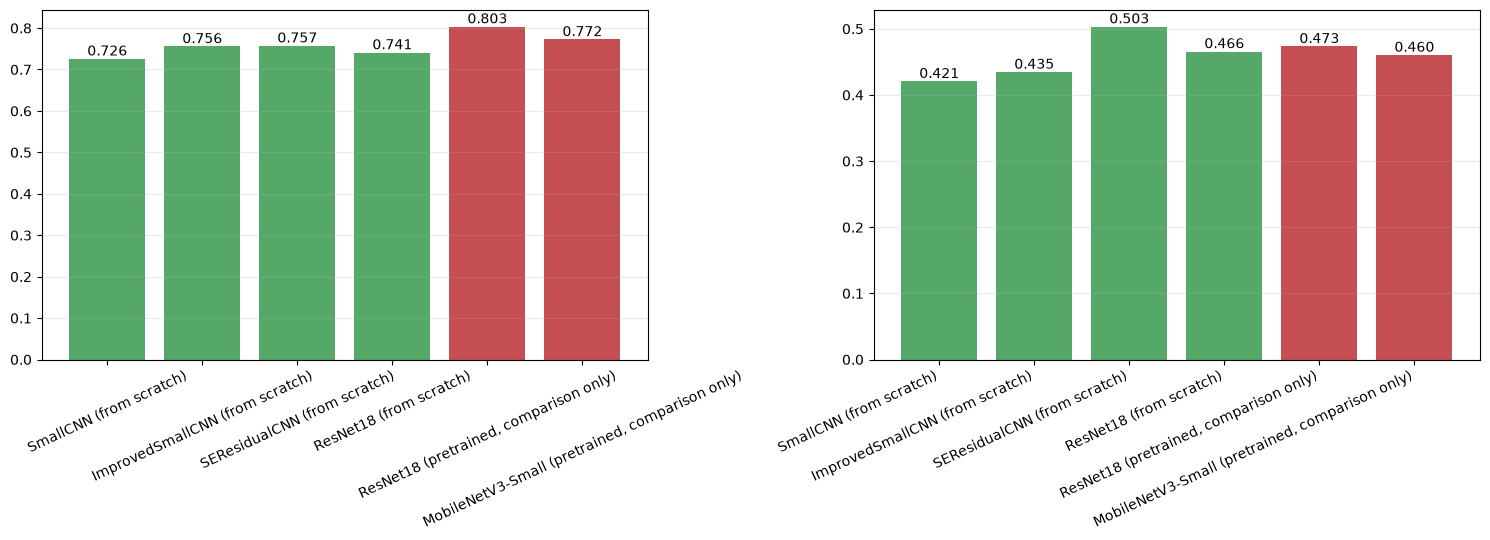

Green = from-scratch (eligible for selection).  Red = pretrained (comparison only).


In [22]:
# ─── 9.2.3 Compare candidates ─────────────────────────────────────────────────
imgonly_candidates_gender = {
    'SmallCNN (from scratch)': {
        'model': gender_imgonly_basiccnn, 'train_f1': tr_f1_g_img_basiccnn,
        'val_f1': f1_g_img_basiccnn, 'from_scratch': True},
    'ImprovedSmallCNN (from scratch)': {
        'model': gender_imgonly_smallcnn, 'train_f1': tr_f1_g_img_smallcnn,
        'val_f1': f1_g_img_smallcnn, 'from_scratch': True},
    'SEResidualCNN (from scratch)': {
        'model': gender_imgonly_seresnet, 'train_f1': tr_f1_g_img_seresnet,
        'val_f1': f1_g_img_seresnet, 'from_scratch': True},
    'ResNet18 (from scratch)': {
        'model': gender_imgonly_resnet18_scratch, 'train_f1': tr_f1_g_img_resnet18_scratch,
        'val_f1': f1_g_img_resnet18_scratch, 'from_scratch': True},
    'ResNet18 (pretrained, comparison only)': {
        'model': gender_imgonly_resnet18, 'train_f1': tr_f1_g_img_resnet18,
        'val_f1': f1_g_img_resnet18, 'from_scratch': False},
    'MobileNetV3-Small (pretrained, comparison only)': {
        'model': gender_imgonly_mobilenet, 'train_f1': tr_f1_g_img_mobilenet,
        'val_f1': f1_g_img_mobilenet, 'from_scratch': False},
}

imgonly_candidates_usage = {
    'SmallCNN (from scratch)': {
        'model': usage_imgonly_basiccnn, 'train_f1': tr_f1_u_img_basiccnn,
        'val_f1': f1_u_img_basiccnn, 'from_scratch': True},
    'ImprovedSmallCNN (from scratch)': {
        'model': usage_imgonly_smallcnn, 'train_f1': tr_f1_u_img_smallcnn,
        'val_f1': f1_u_img_smallcnn, 'from_scratch': True},
    'SEResidualCNN (from scratch)': {
        'model': usage_imgonly_seresnet, 'train_f1': tr_f1_u_img_seresnet,
        'val_f1': f1_u_img_seresnet, 'from_scratch': True},
    'ResNet18 (from scratch)': {
        'model': usage_imgonly_resnet18_scratch, 'train_f1': tr_f1_u_img_resnet18_scratch,
        'val_f1': f1_u_img_resnet18_scratch, 'from_scratch': True},
    'ResNet18 (pretrained, comparison only)': {
        'model': usage_imgonly_resnet18, 'train_f1': tr_f1_u_img_resnet18,
        'val_f1': f1_u_img_resnet18, 'from_scratch': False},
    'MobileNetV3-Small (pretrained, comparison only)': {
        'model': usage_imgonly_mobilenet, 'train_f1': tr_f1_u_img_mobilenet,
        'val_f1': f1_u_img_mobilenet, 'from_scratch': False},
}

imgonly_results_df = pd.DataFrame(
    [{'Label': 'gender', 'Model': name, 'Train Macro-F1': v['train_f1'],
      'Val Macro-F1': v['val_f1'], 'From scratch': v['from_scratch']}
     for name, v in imgonly_candidates_gender.items()]
    +
    [{'Label': 'usage', 'Model': name, 'Train Macro-F1': v['train_f1'],
      'Val Macro-F1': v['val_f1'], 'From scratch': v['from_scratch']}
     for name, v in imgonly_candidates_usage.items()]
)
display(imgonly_results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, candidates, title in zip(
        axes,
        [imgonly_candidates_gender, imgonly_candidates_usage],
        ['Gender — image-only candidates', 'Usage — image-only candidates']):
    names      = list(candidates.keys())
    val_scores = [candidates[n]['val_f1'] for n in names]
    colors     = ['#55A868' if candidates[n]['from_scratch'] else '#C44E52' for n in names]
    bars = ax.bar(names, val_scores, color=colors)
    ax.tick_params(axis='x', rotation=25)

    ax.bar_label(bars, fmt='%.3f')
    ax.grid(axis='y', alpha=0.25)
plt.setp(ax.get_xticklabels(), ha='right')
plt.tight_layout(); plt.show()
print('Green = from-scratch (eligible for selection).  Red = pretrained (comparison only).')


In [23]:
# ─── 9.2.4 Pick the best FROM-SCRATCH-eligible image-only model, per label ────
# Same "fully train your own" rule as everywhere else in this notebook (see
# 9.4/9.6): pretrained backbones are shown above for comparison but can never
# be the model that gets saved/submitted.
def pick_best_image_only(candidates):
    eligible  = {name: v for name, v in candidates.items() if v['from_scratch']}
    best_name = max(eligible, key=lambda n: eligible[n]['val_f1'])
    return best_name, eligible[best_name]

best_gender_imgonly_name, best_gender_imgonly = pick_best_image_only(imgonly_candidates_gender)
best_usage_imgonly_name,  best_usage_imgonly  = pick_best_image_only(imgonly_candidates_usage)

print(f"Best from-scratch image-only GENDER model: {best_gender_imgonly_name}  "
      f"(val Macro-F1={best_gender_imgonly['val_f1']:.4f})")
print(f"Best from-scratch image-only USAGE model:  {best_usage_imgonly_name}  "
      f"(val Macro-F1={best_usage_imgonly['val_f1']:.4f})")

IMAGEONLY_DIR = OUTPUT_DIR / 'image_only'
IMAGEONLY_DIR.mkdir(exist_ok=True)

torch.save(best_gender_imgonly['model'].state_dict(), IMAGEONLY_DIR / 'gender_imageonly_best.pt')
torch.save(best_usage_imgonly['model'].state_dict(),  IMAGEONLY_DIR / 'usage_imageonly_best.pt')

with open(IMAGEONLY_DIR / 'image_only_best_manifest.txt', 'w') as f:
    f.write(f"gender: {best_gender_imgonly_name}  val_macro_f1={best_gender_imgonly['val_f1']:.4f}\n")
    f.write(f"usage:  {best_usage_imgonly_name}  val_macro_f1={best_usage_imgonly['val_f1']:.4f}\n")

print(f"\nSaved best image-only models to {IMAGEONLY_DIR}:")
for f in sorted(IMAGEONLY_DIR.iterdir()):
    print(f"  {f.name}")


Best from-scratch image-only GENDER model: SEResidualCNN (from scratch)  (val Macro-F1=0.7571)
Best from-scratch image-only USAGE model:  SEResidualCNN (from scratch)  (val Macro-F1=0.5033)

Saved best image-only models to ../outputs/task3_models/image_only:
  gender_imageonly_best.pt
  image_only_best_manifest.txt
  usage_imageonly_best.pt


MultiInput-ImprovedCNN (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.7017  va_loss=0.7587  tr_f1=0.7351  va_f1=0.5479  lr=3.00e-04


MultiInput-ImprovedCNN (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ImprovedCNN (gender) 23/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/50 — tr_loss=0.0297  va_loss=0.4605  tr_f1=0.9904  va_f1=0.8156  lr=1.87e-05


MultiInput-ImprovedCNN (gender) 24/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender) 24/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/50 — tr_loss=0.0305  va_loss=0.4949  tr_f1=0.9891  va_f1=0.8104  lr=9.37e-06
Early stopping at epoch 24 (best epoch=14)


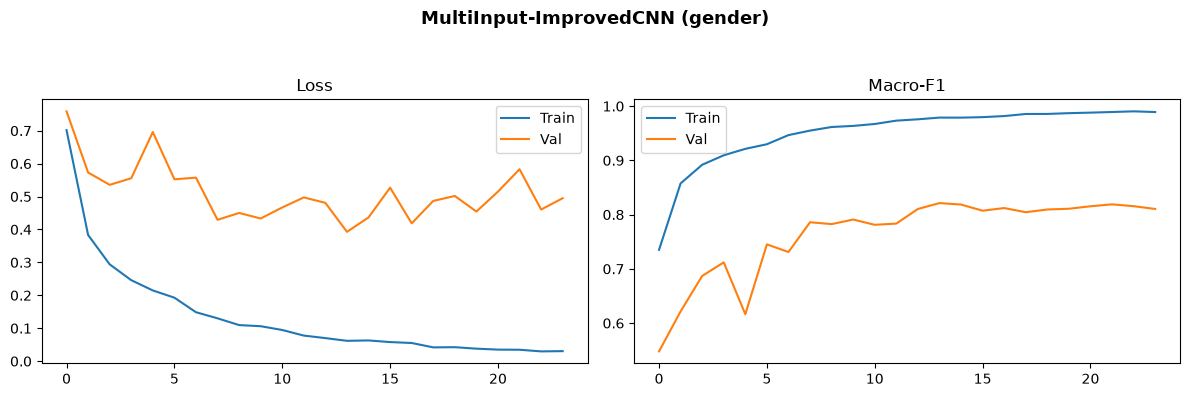

>>> MultiInput-ImprovedCNN (gender): best epoch=14, train_f1=0.9789, val_f1=0.8213
Saved gender model — train_f1=0.9789  val_f1=0.8213


In [24]:
# ─── 9.3 Gender classifier — MultiInput + ImprovedSmallCNN ───────────────────
train_ds_gender = MultiInputDataset(train_data, meta_train, y_gender_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_gender   = MultiInputDataset(val_data,   meta_val,   y_gender_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_gender = DataLoader(train_ds_gender, batch_size=BATCH_SIZE, sampler=sampler_gender,
                                  num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_gender   = DataLoader(val_ds_gender,   batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
gender_model, gender_f1, gender_train_f1, gender_epoch = fit(
    MultiInputNet(META_DIM, N_GENDER, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender, val_loader_gender,
    model_name='MultiInput-ImprovedCNN (gender)'
)

torch.save(gender_model.state_dict(), OUTPUT_DIR / 'gender_multiinput_smallcnn.pt')
print(f'Saved gender model — train_f1={gender_train_f1:.4f}  val_f1={gender_f1:.4f}')


MultiInput-ResNet18Pretrained (gender) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (gender) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.4560  va_loss=0.3911  tr_f1=0.8334  va_f1=0.7667  lr=3.00e-04


MultiInput-ResNet18Pretrained (gender) [comparison only] 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (gender) [comparison only] 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ResNet18Pretrained (gender) [comparison only] 15/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 15/50 — tr_loss=0.0213  va_loss=0.3821  tr_f1=0.9939  va_f1=0.8427  lr=3.75e-05


MultiInput-ResNet18Pretrained (gender) [comparison only] 16/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (gender) [comparison only] 16/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 16/50 — tr_loss=0.0171  va_loss=0.4884  tr_f1=0.9949  va_f1=0.8292  lr=1.87e-05
Early stopping at epoch 16 (best epoch=6)


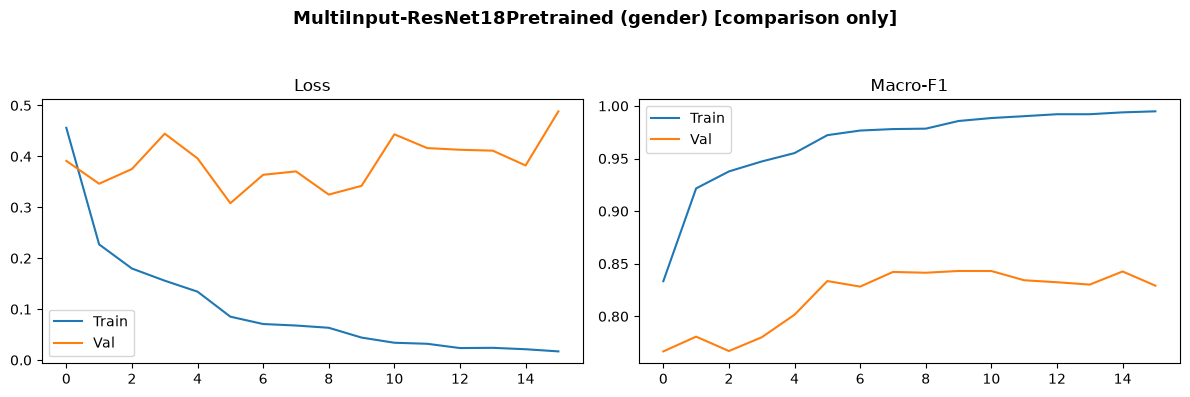

>>> MultiInput-ResNet18Pretrained (gender) [comparison only]: best epoch=6, train_f1=0.9722, val_f1=0.8336
Pretrained ResNet18 gender (comparison only) — train_f1=0.9722  val_f1=0.8336


In [25]:
# ─── 9.4 Gender classifier — MultiInput + Pretrained ResNet18 ────────────────
# NOTE: this backbone is ImageNet-pretrained (see PretrainedResNet18Encoder in
# Section 8). The assignment spec requires the FINAL/submitted model to be
# fully trained from scratch, and only allows pretrained models "for
# comparison". This model is therefore kept in the results table/bar chart
# below for comparison, but is explicitly EXCLUDED from best-model selection
# in Section 12 (see the "from-scratch only" candidate dict there).
torch.manual_seed(RANDOM_STATE)
gender_resnet_model, gender_resnet_f1, gender_resnet_train_f1, gender_resnet_epoch = fit(
    MultiInputNet(META_DIM, N_GENDER, PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_gender, val_loader_gender,
    model_name='MultiInput-ResNet18Pretrained (gender) [comparison only]'
)
print(f'Pretrained ResNet18 gender (comparison only) — train_f1={gender_resnet_train_f1:.4f}  val_f1={gender_resnet_f1:.4f}')


MultiInput-ImprovedCNN (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.4798  va_loss=0.6946  tr_f1=0.8414  va_f1=0.4658  lr=3.00e-04


MultiInput-ImprovedCNN (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (usage) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ImprovedCNN (usage) 21/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 21/50 — tr_loss=0.0220  va_loss=0.5428  tr_f1=0.9937  va_f1=0.5051  lr=3.75e-05


MultiInput-ImprovedCNN (usage) 22/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (usage) 22/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 22/50 — tr_loss=0.0213  va_loss=0.5815  tr_f1=0.9938  va_f1=0.5030  lr=1.87e-05
Early stopping at epoch 22 (best epoch=12)


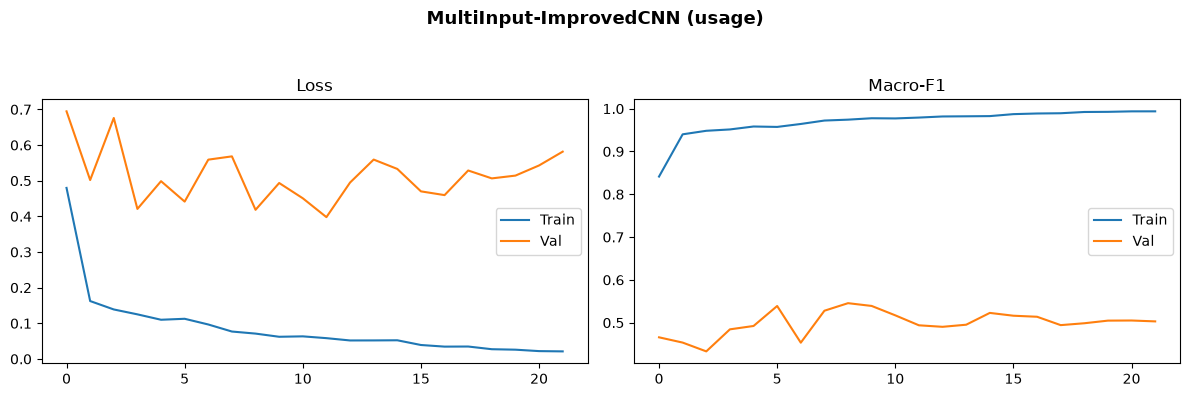

>>> MultiInput-ImprovedCNN (usage): best epoch=12, train_f1=0.9792, val_f1=0.4939
Saved usage model — train_f1=0.9792  val_f1=0.4939


In [26]:
# ─── 9.5 Usage classifier — MultiInput + ImprovedSmallCNN ────────────────────
train_ds_usage = MultiInputDataset(train_data, meta_train, y_usage_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_usage   = MultiInputDataset(val_data,   meta_val,   y_usage_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_usage = DataLoader(train_ds_usage, batch_size=BATCH_SIZE, sampler=sampler_usage,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_usage   = DataLoader(val_ds_usage,   batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
usage_model, usage_f1, usage_train_f1, usage_epoch = fit(
    MultiInputNet(META_DIM, N_USAGE, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage, val_loader_usage,
    model_name='MultiInput-ImprovedCNN (usage)'
)

torch.save(usage_model.state_dict(), OUTPUT_DIR / 'usage_multiinput_smallcnn.pt')
print(f'Saved usage model — train_f1={usage_train_f1:.4f}  val_f1={usage_f1:.4f}')


MultiInput-ResNet18Pretrained (usage) [comparison only] 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (usage) [comparison only] 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.3141  va_loss=0.4867  tr_f1=0.8888  va_f1=0.5630  lr=3.00e-04


MultiInput-ResNet18Pretrained (usage) [comparison only] 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (usage) [comparison only] 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ResNet18Pretrained (usage) [comparison only] 16/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 16/50 — tr_loss=0.0155  va_loss=0.4265  tr_f1=0.9963  va_f1=0.5115  lr=3.75e-05


MultiInput-ResNet18Pretrained (usage) [comparison only] 17/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (usage) [comparison only] 17/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 17/50 — tr_loss=0.0156  va_loss=0.4715  tr_f1=0.9957  va_f1=0.5115  lr=1.87e-05
Early stopping at epoch 17 (best epoch=7)


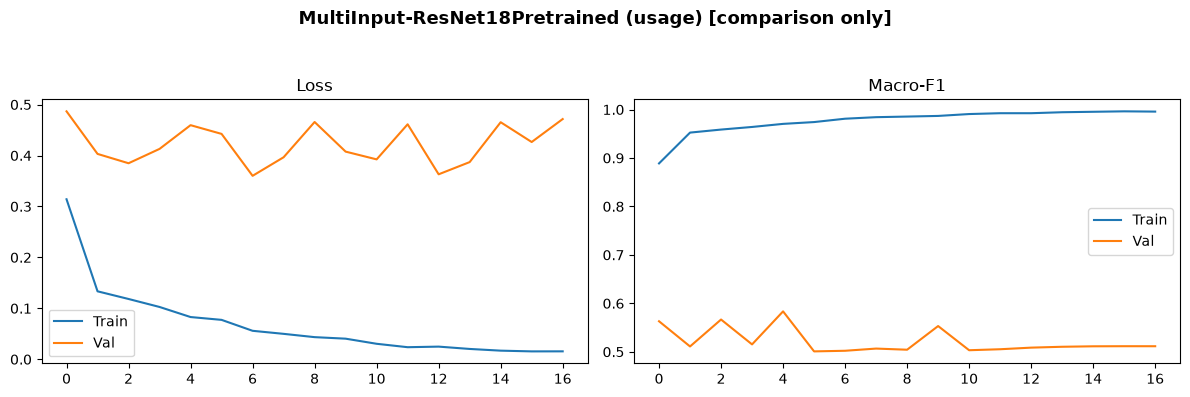

>>> MultiInput-ResNet18Pretrained (usage) [comparison only]: best epoch=7, train_f1=0.9811, val_f1=0.5021
Pretrained ResNet18 usage (comparison only) — train_f1=0.9811  val_f1=0.5021


In [27]:
# ─── 9.6 Usage classifier — MultiInput + Pretrained ResNet18 ─────────────────
# NOTE: comparison-only — see the note in 9.4. Excluded from best-model
# selection in Section 12.
torch.manual_seed(RANDOM_STATE)
usage_resnet_model, usage_resnet_f1, usage_resnet_train_f1, usage_resnet_epoch = fit(
    MultiInputNet(META_DIM, N_USAGE, PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_usage, val_loader_usage,
    model_name='MultiInput-ResNet18Pretrained (usage) [comparison only]'
)
print(f'Pretrained ResNet18 usage (comparison only) — train_f1={usage_resnet_train_f1:.4f}  val_f1={usage_resnet_f1:.4f}')


### 9.7 Second fusion strategy — Gated Fusion (image + metadata)

Concatenation (used by `MultiInputNet` above) always weighs both modalities equally. Gated
fusion lets the model learn, per sample, how much to rely on the image vs. the metadata branch.
This is the additional fusion strategy investigated beyond plain concatenation.

GatedFusion-ImprovedCNN (gender) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-ImprovedCNN (gender) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.7341  va_loss=0.5210  tr_f1=0.7122  va_f1=0.7049  lr=3.00e-04


GatedFusion-ImprovedCNN (gender) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-ImprovedCNN (gender) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

GatedFusion-ImprovedCNN (gender) 13/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 13/50 — tr_loss=0.0773  va_loss=0.5458  tr_f1=0.9726  va_f1=0.7702  lr=7.50e-05


GatedFusion-ImprovedCNN (gender) 14/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-ImprovedCNN (gender) 14/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 14/50 — tr_loss=0.0625  va_loss=0.5150  tr_f1=0.9795  va_f1=0.8131  lr=3.75e-05
Early stopping at epoch 14 (best epoch=4)


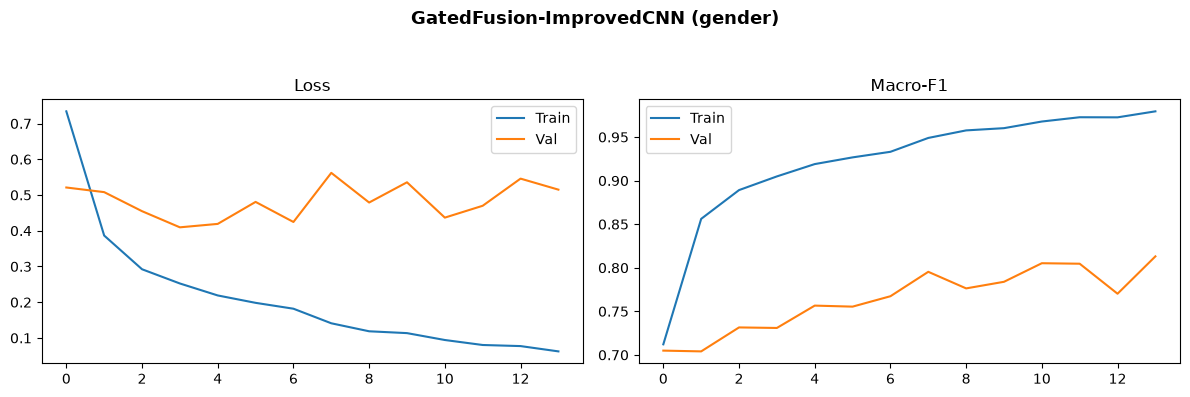

>>> GatedFusion-ImprovedCNN (gender): best epoch=4, train_f1=0.9049, val_f1=0.7309
Saved gated-fusion gender model — train_f1=0.9049  val_f1=0.7309


In [28]:
torch.manual_seed(RANDOM_STATE)
gender_gated_model, gender_gated_f1, gender_gated_train_f1, gender_gated_epoch = fit(
    GatedFusionNet(META_DIM, N_GENDER, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender, val_loader_gender,
    model_name='GatedFusion-ImprovedCNN (gender)'
)

torch.save(gender_gated_model.state_dict(), OUTPUT_DIR / 'gender_gatedfusion.pt')
print(f'Saved gated-fusion gender model — train_f1={gender_gated_train_f1:.4f}  val_f1={gender_gated_f1:.4f}')

GatedFusion-ImprovedCNN (usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-ImprovedCNN (usage) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.5565  va_loss=0.7706  tr_f1=0.8034  va_f1=0.4629  lr=3.00e-04


GatedFusion-ImprovedCNN (usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-ImprovedCNN (usage) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

GatedFusion-ImprovedCNN (usage) 16/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 16/50 — tr_loss=0.0402  va_loss=0.4955  tr_f1=0.9869  va_f1=0.5489  lr=7.50e-05


GatedFusion-ImprovedCNN (usage) 17/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

GatedFusion-ImprovedCNN (usage) 17/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 17/50 — tr_loss=0.0372  va_loss=0.5254  tr_f1=0.9881  va_f1=0.5001  lr=3.75e-05
Early stopping at epoch 17 (best epoch=7)


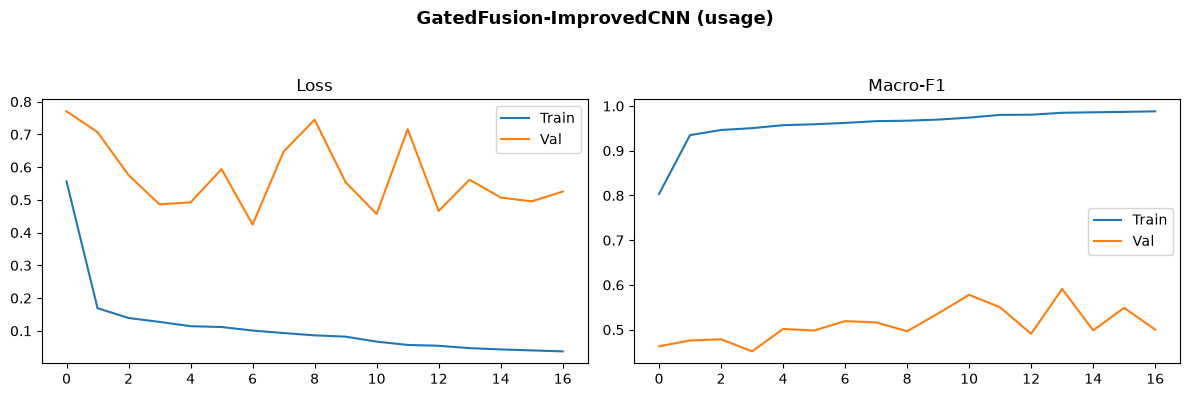

>>> GatedFusion-ImprovedCNN (usage): best epoch=7, train_f1=0.9622, val_f1=0.5191
Saved gated-fusion usage model — train_f1=0.9622  val_f1=0.5191


In [29]:
torch.manual_seed(RANDOM_STATE)
usage_gated_model, usage_gated_f1, usage_gated_train_f1, usage_gated_epoch = fit(
    GatedFusionNet(META_DIM, N_USAGE, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage, val_loader_usage,
    model_name='GatedFusion-ImprovedCNN (usage)'
)

torch.save(usage_gated_model.state_dict(), OUTPUT_DIR / 'usage_gatedfusion.pt')
print(f'Saved gated-fusion usage model — train_f1={usage_gated_train_f1:.4f}  val_f1={usage_gated_f1:.4f}')

### 9.8 Soft-voting ensemble (LogReg ⊕ SmallCNN) — no extra training

An unweighted (50/50) soft vote between the metadata-only LogReg baseline and the
image+metadata SmallCNN, computed directly from probabilities already produced by models
trained above — no new network is trained for this model.

In [30]:
def get_cnn_probs(model, loader):
    """Softmax probabilities from a MultiInputNet-style model, in loader order
    (loader must have shuffle=False so the order lines up with a metadata array)."""
    model.eval(); probs = []
    with torch.no_grad():
        for batch in loader:
            inputs, _ = to_device(batch)
            probs.append(torch.softmax(model(*inputs), dim=1).cpu().numpy())
    return np.concatenate(probs, axis=0)

# Eval-mode (shuffle=False, no weighted sampler) loaders so CNN output order
# matches the plain row order of meta_train / meta_val used by LogReg.
train_loader_gender_eval = DataLoader(train_ds_gender, batch_size=BATCH_SIZE, shuffle=False,
                                       num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
train_loader_usage_eval  = DataLoader(train_ds_usage,  batch_size=BATCH_SIZE, shuffle=False,
                                       num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

def soft_vote_f1(cnn_model, logreg_model, loader, meta, y_true):
    cnn_probs    = get_cnn_probs(cnn_model, loader)
    logreg_probs = logreg_model.predict_proba(meta)
    vote_probs   = 0.5 * cnn_probs + 0.5 * logreg_probs
    preds        = vote_probs.argmax(1)
    return f1_score(y_true, preds, average='macro', zero_division=0)

f1_g_softvote_train = soft_vote_f1(gender_model, logreg_gender, train_loader_gender_eval, meta_train, y_gender_train)
f1_g_softvote       = soft_vote_f1(gender_model, logreg_gender, val_loader_gender,        meta_val,   y_gender_val)
f1_u_softvote_train = soft_vote_f1(usage_model,  logreg_usage,  train_loader_usage_eval,  meta_train, y_usage_train)
f1_u_softvote       = soft_vote_f1(usage_model,  logreg_usage,  val_loader_usage,         meta_val,   y_usage_val)

print(f'Soft-voting ensemble — gender: train_f1={f1_g_softvote_train:.4f}  val_f1={f1_g_softvote:.4f}')
print(f'Soft-voting ensemble — usage:  train_f1={f1_u_softvote_train:.4f}  val_f1={f1_u_softvote:.4f}')

Soft-voting ensemble — gender: train_f1=0.9392  val_f1=0.8108
Soft-voting ensemble — usage:  train_f1=0.7121  val_f1=0.5177


## 10. Approach B — Single combined-label classifier (gender × usage)

Treats gender_usage as one combined class. Learns the joint distribution but has more classes and sparser per-class data.

MultiInput-ImprovedCNN (gender x usage combined) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender x usage combined) 1/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=1.1687  va_loss=1.1769  tr_f1=0.6372  va_f1=0.3734  lr=3.00e-04


MultiInput-ImprovedCNN (gender x usage combined) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender x usage combined) 2/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ImprovedCNN (gender x usage combined) 27/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 27/50 — tr_loss=0.0547  va_loss=1.0059  tr_f1=0.9827  va_f1=0.5442  lr=9.37e-06


MultiInput-ImprovedCNN (gender x usage combined) 28/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender x usage combined) 28/50 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 28/50 — tr_loss=0.0511  va_loss=0.8821  tr_f1=0.9842  va_f1=0.5729  lr=4.69e-06
Early stopping at epoch 28 (best epoch=18)


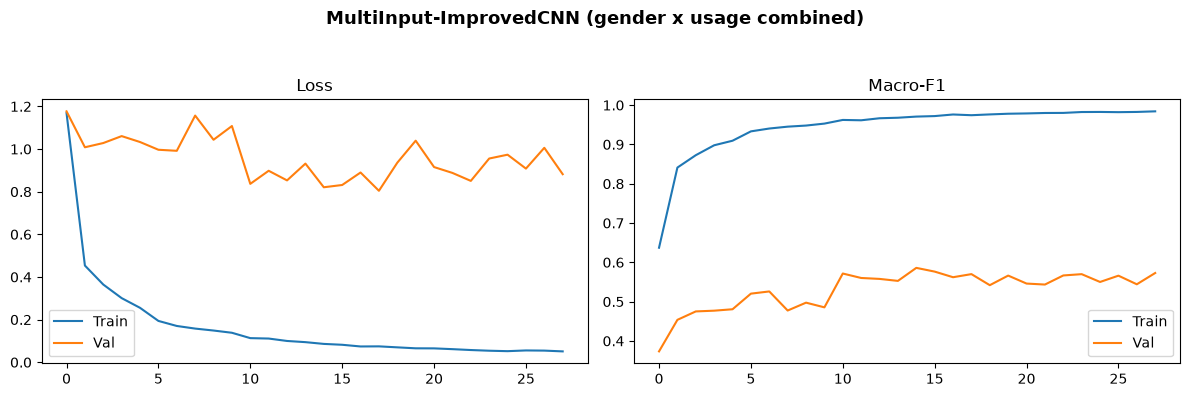

>>> MultiInput-ImprovedCNN (gender x usage combined): best epoch=18, train_f1=0.9743, val_f1=0.5700
Saved combined model — train_f1(joint)=0.9743  val_f1(joint)=0.5700


In [31]:
y_combined_train = train_data['gender_usage_label'].values
y_combined_val   = val_data['gender_usage_label'].values
sampler_combined = get_weighted_sampler(train_data, 'gender_usage_label')

train_ds_combined = MultiInputDataset(train_data, meta_train, y_combined_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_combined   = MultiInputDataset(val_data,   meta_val,   y_combined_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_combined = DataLoader(train_ds_combined, batch_size=BATCH_SIZE, sampler=sampler_combined,
                                    num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_combined   = DataLoader(val_ds_combined,   batch_size=BATCH_SIZE, shuffle=False,
                                    num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
combined_model, combined_f1, combined_train_f1, combined_epoch = fit(
    MultiInputNet(META_DIM, N_COMBINED, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_combined, val_loader_combined,
    model_name='MultiInput-ImprovedCNN (gender x usage combined)'
)
# NOTE: combined_train_f1 above is macro-F1 on the JOINT gender__usage label —
# not directly comparable to the per-target (gender-only / usage-only) F1
# used elsewhere. Section 12 decodes train-set predictions back into gender
# and usage separately (f1_g_combined_train / f1_u_combined_train) so the
# train-vs-val bar chart compares like with like.

torch.save(combined_model.state_dict(), OUTPUT_DIR / 'combined_gender_usage_smallcnn.pt')
print(f'Saved combined model — train_f1(joint)={combined_train_f1:.4f}  val_f1(joint)={combined_f1:.4f}')


## 11. Approach C — Dual-head model (shared backbone, two heads)

Trains one model that simultaneously predicts both gender and usage from a shared representation.
Loss = α × gender_loss + (1−α) × usage_loss.

DualHead-ImprovedCNN (gender + usage) 1/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

Epoch 1/50 — tr_loss=0.5339  va_loss=0.4869  tr_f1_g=0.4205  tr_f1_u=0.3909  va_f1_g=0.5038  va_f1_u=0.4787


DualHead-ImprovedCNN (gender + usage) 2/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

Epoch 2/50 — tr_loss=0.3032  va_loss=0.3325  tr_f1_g=0.6505  tr_f1_u=0.4911  va_f1_g=0.6861  va_f1_u=0.4886


DualHead-ImprovedCNN (gender + usage) 3/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

Epoch 16/50 — tr_loss=0.0935  va_loss=0.3391  tr_f1_g=0.8972  tr_f1_u=0.5590  va_f1_g=0.7776  va_f1_u=0.5685


DualHead-ImprovedCNN (gender + usage) 17/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

Epoch 17/50 — tr_loss=0.0864  va_loss=0.3344  tr_f1_g=0.9108  tr_f1_u=0.5991  va_f1_g=0.7806  va_f1_u=0.5591


DualHead-ImprovedCNN (gender + usage) 18/50 train:   0%|          | 0/443 [00:00<?, ?it/s]

Epoch 18/50 — tr_loss=0.0734  va_loss=0.3512  tr_f1_g=0.9161  tr_f1_u=0.5818  va_f1_g=0.7773  va_f1_u=0.5550
Early stopping at epoch 18 (best=8)


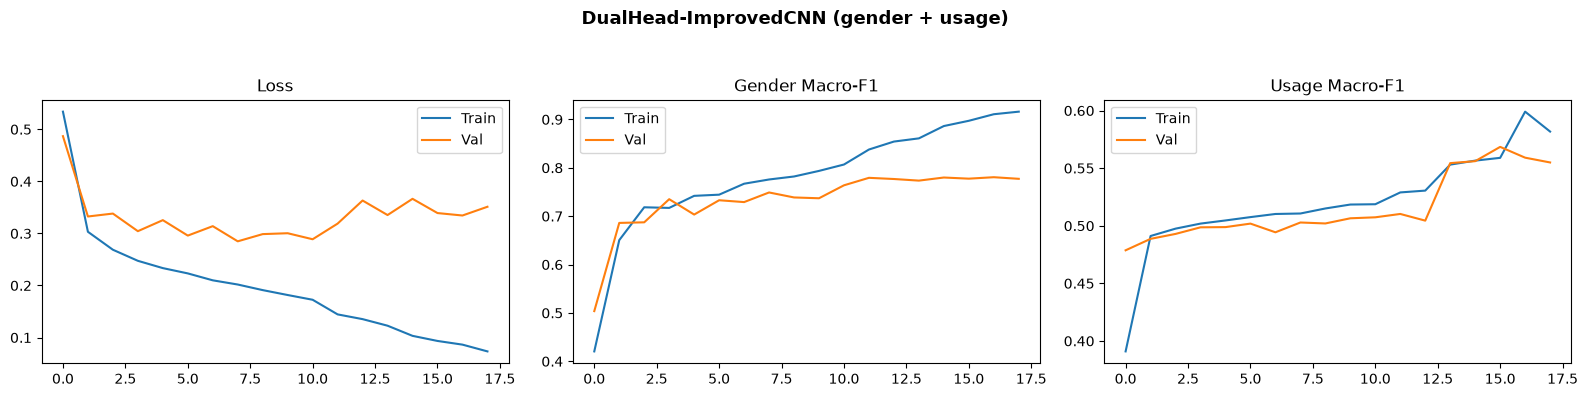

>>> Best epoch=8  train_f1_gender=0.7759  val_f1_gender=0.7490  train_f1_usage=0.5107  val_f1_usage=0.5028
Dual-head saved — gender: train_f1=0.7759 val_f1=0.7490  usage: train_f1=0.5107 val_f1=0.5028


In [32]:
ALPHA = 0.5   # weight balance between gender and usage losses

train_ds_dual = DualLabelDataset(
    train_data, meta_train, y_gender_train, y_usage_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_dual   = DualLabelDataset(
    val_data,   meta_val,   y_gender_val,   y_usage_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_dual = DataLoader(train_ds_dual, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_dual   = DataLoader(val_ds_dual,   batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))


def fit_dual(model, loader_tr, loader_va, model_name='dual_model', patience=PATIENCE, lr=LR):
    """Training loop for the dual-head model. Returns gender/usage F1 for
    both train (at best epoch) and val."""
    criterion  = nn.CrossEntropyLoss()
    optimiser  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    stopper    = EarlyStopping(patience=patience, mode='min')
    history    = {'train_loss': [], 'val_loss': [], 'train_f1_g': [], 'train_f1_u': [],
                  'val_f1_g':   [], 'val_f1_u': []}
    best_val_loss = None; best_epoch = None
    best_val_f1_g = None; best_val_f1_u = None
    # FIX: also track train F1 at the best epoch (for train-vs-val comparison)
    best_train_f1_g = None; best_train_f1_u = None

    for epoch in range(EPOCHS):
        # ── Train ──
        model.train()
        tr_loss, tr_pg, tr_pu, tr_ag, tr_au = 0.0, [], [], [], []
        for img, meta, g_lbl, u_lbl in tqdm(loader_tr, desc=f'{model_name} {epoch+1}/{EPOCHS} train', leave=True):
            img, meta, g_lbl, u_lbl = img.to(DEVICE), meta.to(DEVICE), g_lbl.to(DEVICE), u_lbl.to(DEVICE)
            g_logit, u_logit = model(img, meta)
            loss = ALPHA * criterion(g_logit, g_lbl) + (1 - ALPHA) * criterion(u_logit, u_lbl)
            optimiser.zero_grad(); loss.backward(); optimiser.step()
            tr_loss += loss.item() * g_lbl.size(0)
            tr_pg.extend(g_logit.argmax(1).cpu().numpy()); tr_ag.extend(g_lbl.cpu().numpy())
            tr_pu.extend(u_logit.argmax(1).cpu().numpy()); tr_au.extend(u_lbl.cpu().numpy())
        tr_loss /= len(train_data)
        tr_f1_g = f1_score(tr_ag, tr_pg, average='macro', zero_division=0)
        tr_f1_u = f1_score(tr_au, tr_pu, average='macro', zero_division=0)

        # ── Validate ──
        model.eval()
        va_loss, va_pg, va_pu, va_ag, va_au = 0.0, [], [], [], []
        with torch.no_grad():
            for img, meta, g_lbl, u_lbl in loader_va:
                img, meta, g_lbl, u_lbl = img.to(DEVICE), meta.to(DEVICE), g_lbl.to(DEVICE), u_lbl.to(DEVICE)
                g_logit, u_logit = model(img, meta)
                loss = ALPHA * criterion(g_logit, g_lbl) + (1 - ALPHA) * criterion(u_logit, u_lbl)
                va_loss += loss.item() * g_lbl.size(0)
                va_pg.extend(g_logit.argmax(1).cpu().numpy()); va_ag.extend(g_lbl.cpu().numpy())
                va_pu.extend(u_logit.argmax(1).cpu().numpy()); va_au.extend(u_lbl.cpu().numpy())
        va_loss /= len(val_data)
        va_f1_g = f1_score(va_ag, va_pg, average='macro', zero_division=0)
        va_f1_u = f1_score(va_au, va_pu, average='macro', zero_division=0)

        for k, v in zip(['train_loss','val_loss','train_f1_g','train_f1_u','val_f1_g','val_f1_u'],
                         [tr_loss, va_loss, tr_f1_g, tr_f1_u, va_f1_g, va_f1_u]):
            history[k].append(v)

        print(f'Epoch {epoch+1}/{EPOCHS} — tr_loss={tr_loss:.4f}  va_loss={va_loss:.4f}  '
              f'tr_f1_g={tr_f1_g:.4f}  tr_f1_u={tr_f1_u:.4f}  '
              f'va_f1_g={va_f1_g:.4f}  va_f1_u={va_f1_u:.4f}')

        scheduler.step(va_loss)
        stopper(va_loss, model)
        if stopper.counter == 0:
            best_val_loss = va_loss; best_epoch = epoch + 1
            best_val_f1_g = va_f1_g; best_val_f1_u = va_f1_u
            best_train_f1_g = tr_f1_g; best_train_f1_u = tr_f1_u
        if stopper.early_stop:
            print(f'Early stopping at epoch {epoch+1} (best={best_epoch})')
            break

    model = stopper.load_best_model(model)

    # Plot training curves
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(model_name, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history['train_f1_g'], label='Train'); axes[1].plot(history['val_f1_g'], label='Val')
    axes[1].set_title('Gender Macro-F1'); axes[1].legend()
    axes[2].plot(history['train_f1_u'], label='Train'); axes[2].plot(history['val_f1_u'], label='Val')
    axes[2].set_title('Usage Macro-F1'); axes[2].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

    print(f'>>> Best epoch={best_epoch}  '
          f'train_f1_gender={best_train_f1_g:.4f}  val_f1_gender={best_val_f1_g:.4f}  '
          f'train_f1_usage={best_train_f1_u:.4f}  val_f1_usage={best_val_f1_u:.4f}')
    return model, best_val_f1_g, best_val_f1_u, best_train_f1_g, best_train_f1_u, best_epoch


torch.manual_seed(RANDOM_STATE)
dual_model, dual_f1_g, dual_f1_u, dual_train_f1_g, dual_train_f1_u, dual_epoch = fit_dual(
    DualHeadNet(META_DIM, N_GENDER, N_USAGE, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_dual, val_loader_dual,
    model_name='DualHead-ImprovedCNN (gender + usage)'
)

torch.save(dual_model.state_dict(), OUTPUT_DIR / 'dual_head_gender_usage.pt')
print(f'Dual-head saved — gender: train_f1={dual_train_f1_g:.4f} val_f1={dual_f1_g:.4f}  '
      f'usage: train_f1={dual_train_f1_u:.4f} val_f1={dual_f1_u:.4f}')


## 12. Evaluation & comparison across all approaches

In [33]:
# ── Helper: evaluate dual-head on val set ────────────────────────────────────
def evaluate_dual(model, loader):
    model.eval(); pg, pu, ag, au = [], [], [], []
    with torch.no_grad():
        for img, meta, g_lbl, u_lbl in loader:
            img, meta = img.to(DEVICE), meta.to(DEVICE)
            g_logit, u_logit = model(img, meta)
            pg.extend(g_logit.argmax(1).cpu().numpy()); ag.extend(g_lbl.numpy())
            pu.extend(u_logit.argmax(1).cpu().numpy()); au.extend(u_lbl.numpy())
    f1_g = f1_score(ag, pg, average='macro', zero_division=0)
    f1_u = f1_score(au, pu, average='macro', zero_division=0)
    return f1_g, f1_u, np.array(pg), np.array(pu), np.array(ag), np.array(au)


def decode_combined_predictions(model, loader, frame):
    """Run the combined-label model over `loader` and split its joint
    prediction back into (gender, usage), scored against `frame`'s true
    per-target labels. Used for both val and train sets so the gender/usage
    bar chart has a matching basis for each approach."""
    model.eval(); preds = []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            preds.extend(model(*inputs).argmax(1).cpu().numpy())
    decoded      = gender_usage_enc.inverse_transform(preds)
    pred_gender  = [gender_enc.transform([c.split('__')[0]])[0] for c in decoded]
    pred_usage   = [usage_enc.transform([c.split('__')[1]])[0]  for c in decoded]
    true_gender  = frame['gender_label'].values
    true_usage   = frame['usage_label'].values
    f1_g = f1_score(true_gender, pred_gender, average='macro', zero_division=0)
    f1_u = f1_score(true_usage,  pred_usage,  average='macro', zero_division=0)
    return f1_g, f1_u, np.array(pred_gender), np.array(pred_usage), true_gender, true_usage


# ── Run evaluations ───────────────────────────────────────────────────────────
# Approach A
f1_g_cnn    = evaluate(gender_model,        val_loader_gender)
f1_g_resnet = evaluate(gender_resnet_model, val_loader_gender)
f1_u_cnn    = evaluate(usage_model,         val_loader_usage)
f1_u_resnet = evaluate(usage_resnet_model,  val_loader_usage)

# Approach B — decode combined label back to gender/usage, VAL set
f1_g_combined, f1_u_combined, pred_gender_B, pred_usage_B, true_gender_B, true_usage_B = \
    decode_combined_predictions(combined_model, val_loader_combined, val_data)

# Approach B — same decode, TRAIN set (for the train-vs-val bar chart).
# NOTE: train_loader_combined uses a WeightedRandomSampler, so a single pass
# over it does not sample every training row uniformly. This matches the
# basis fit() already uses for the training-curve plots elsewhere in this
# notebook, but it is a different sampling basis than the LogReg train F1
# (computed on the raw, unsampled distribution) — worth a one-line caveat if
# you quote these numbers in the report.
f1_g_combined_train, f1_u_combined_train, _, _, _, _ = \
    decode_combined_predictions(combined_model, train_loader_combined, train_data)

# Approach C — single pass, keep raw predictions (previously this was re-run
# two more times in the confusion-matrix cell for no reason)
f1_g_dual, f1_u_dual, pg_dual, pu_dual, ag_dual, au_dual = evaluate_dual(dual_model, val_loader_dual)


# Gated Fusion (Section 9.7) — extra fusion strategy, evaluated the same way as Approach A
f1_g_gated = evaluate(gender_gated_model, val_loader_gender)
f1_u_gated = evaluate(usage_gated_model,  val_loader_usage)


In [34]:
# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Model': [
        'LogReg (metadata baseline)',
        'A — MultiInput-SmallCNN (gender, concatenation)',
        'A — MultiInput-SmallCNN (usage, concatenation)',
        'A — MultiInput-ResNet18 (gender) [pretrained, comparison only]',
        'A — MultiInput-ResNet18 (usage) [pretrained, comparison only]',
        'A — MultiInput-GatedFusion (gender)',
        'A — MultiInput-GatedFusion (usage)',
        'A — Soft-Voting Ensemble (gender)',
        'A — Soft-Voting Ensemble (usage)',
        'B — Combined (gender decoded)',
        'B — Combined (usage decoded)',
        'C — DualHead (gender head)',
        'C — DualHead (usage head)',
    ],
    'Target': [
        'gender+usage', 'gender', 'usage', 'gender', 'usage',
        'gender', 'usage', 'gender', 'usage',
        'gender', 'usage', 'gender', 'usage'
    ],
    'Train Macro-F1 (gender)': [
        logreg_gender_train_f1, gender_train_f1, None, gender_resnet_train_f1, None,
        gender_gated_train_f1, None, f1_g_softvote_train, None,
        f1_g_combined_train, None, dual_train_f1_g, None
    ],
    'Val Macro-F1 (gender)': [
        logreg_gender_f1, f1_g_cnn, None, f1_g_resnet, None,
        f1_g_gated, None, f1_g_softvote, None,
        f1_g_combined, None, f1_g_dual, None
    ],
    'Train Macro-F1 (usage)': [
        logreg_usage_train_f1, None, usage_train_f1, None, usage_resnet_train_f1,
        None, usage_gated_train_f1, None, f1_u_softvote_train,
        None, f1_u_combined_train, None, dual_train_f1_u
    ],
    'Val Macro-F1 (usage)': [
        logreg_usage_f1, None, f1_u_cnn, None, f1_u_resnet,
        None, f1_u_gated, None, f1_u_softvote,
        None, f1_u_combined, None, f1_u_dual
    ],
})

display(results_df.round(4))


,Model,Target,Train Macro-F1 (gender),Val Macro-F1 (gender),Train Macro-F1 (usage),Val Macro-F1 (usage)
0,LogReg (metadata baseline),gender+usage,0.4394,0.4415,0.4153,0.4032
1,"A — MultiInput-SmallCNN (gender, concatenation)",gender,0.9789,0.8213,NaN,NaN
2,"A — MultiInput-SmallCNN (usage, concatenation)",usage,NaN,NaN,0.9792,0.4939
3,"A — MultiInput-ResNet18 (gender) [pretrained, ...",gender,0.9722,0.8336,NaN,NaN
4,"A — MultiInput-ResNet18 (usage) [pretrained, c...",usage,NaN,NaN,0.9811,0.5021
5,A — MultiInput-GatedFusion (gender),gender,0.9049,0.7309,NaN,NaN
6,A — MultiInput-GatedFusion (usage),usage,NaN,NaN,0.9622,0.5191
7,A — Soft-Voting Ensemble (gender),gender,0.9392,0.8108,NaN,NaN
8,A — Soft-Voting Ensemble (usage),usage,NaN,NaN,0.7121,0.5177
9,B — Combined (gender decoded),gender,0.1641,0.7954,NaN,NaN


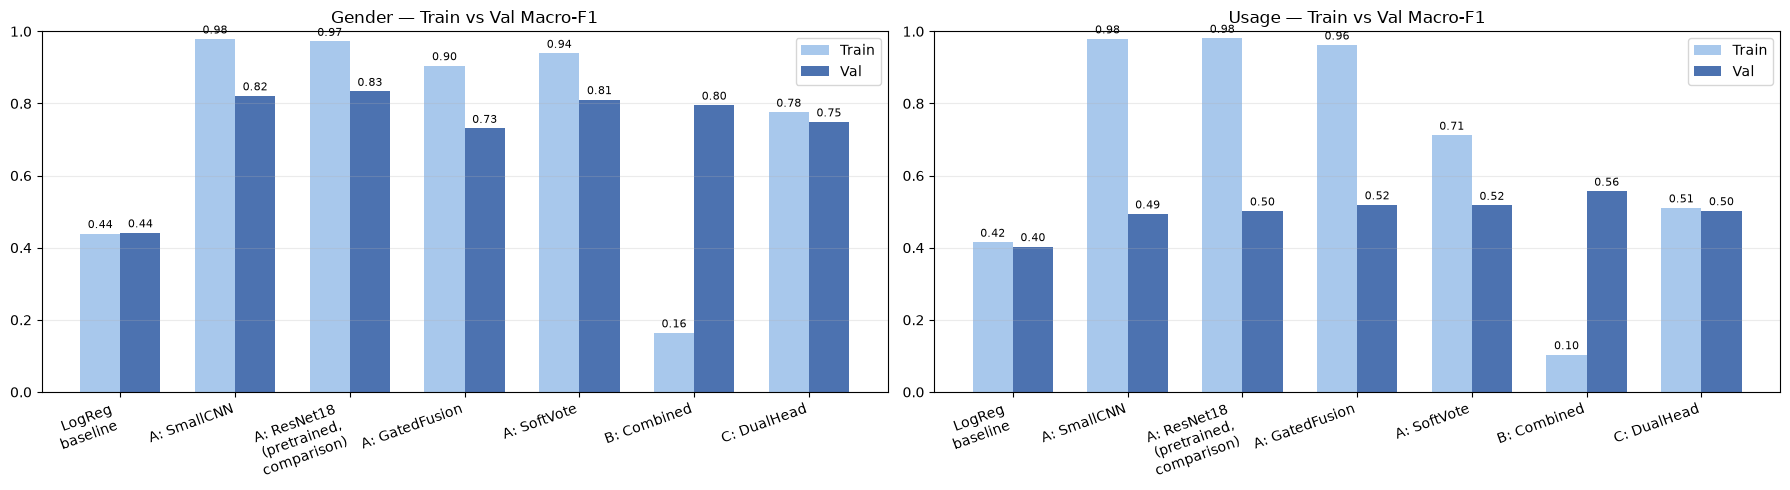

In [35]:
# ── Bar chart comparison: Train vs Validation Macro-F1 ───────────────────────
labels = ['LogReg\nbaseline', 'A: SmallCNN', 'A: ResNet18\n(pretrained,\ncomparison)',
          'A: GatedFusion', 'A: SoftVote', 'B: Combined', 'C: DualHead']

gender_train_scores = [logreg_gender_train_f1, gender_train_f1, gender_resnet_train_f1,
                        gender_gated_train_f1, f1_g_softvote_train, f1_g_combined_train, dual_train_f1_g]
gender_val_scores   = [logreg_gender_f1,       f1_g_cnn,        f1_g_resnet,
                        f1_g_gated,             f1_g_softvote,       f1_g_combined,       f1_g_dual]

usage_train_scores  = [logreg_usage_train_f1,  usage_train_f1,  usage_resnet_train_f1,
                        usage_gated_train_f1,   f1_u_softvote_train, f1_u_combined_train, dual_train_f1_u]
usage_val_scores    = [logreg_usage_f1,        f1_u_cnn,        f1_u_resnet,
                        f1_u_gated,             f1_u_softvote,       f1_u_combined,       f1_u_dual]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, train_scores, val_scores, title in zip(
        axes,
        [gender_train_scores, usage_train_scores],
        [gender_val_scores, usage_val_scores],
        ['Gender — Train vs Val Macro-F1', 'Usage — Train vs Val Macro-F1']):
    x = np.arange(len(labels))
    width = 0.35
    bars_tr = ax.bar(x - width / 2, train_scores, width, label='Train', color='#A8C8EC')
    bars_va = ax.bar(x + width / 2, val_scores,   width, label='Val',   color='#4C72B0')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylim(0, 1); ax.set_title(title)
    ax.bar_label(bars_tr, fmt='%.2f', padding=2, fontsize=8)
    ax.bar_label(bars_va, fmt='%.2f', padding=2, fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()


Best gender model (from-scratch only): SmallCNN (val_f1=0.8213)
Best usage model  (from-scratch only): Combined  (val_f1=0.5569)
[Reference — pretrained, not eligible for selection] ResNet18 gender val_f1=0.8336, usage val_f1=0.5021


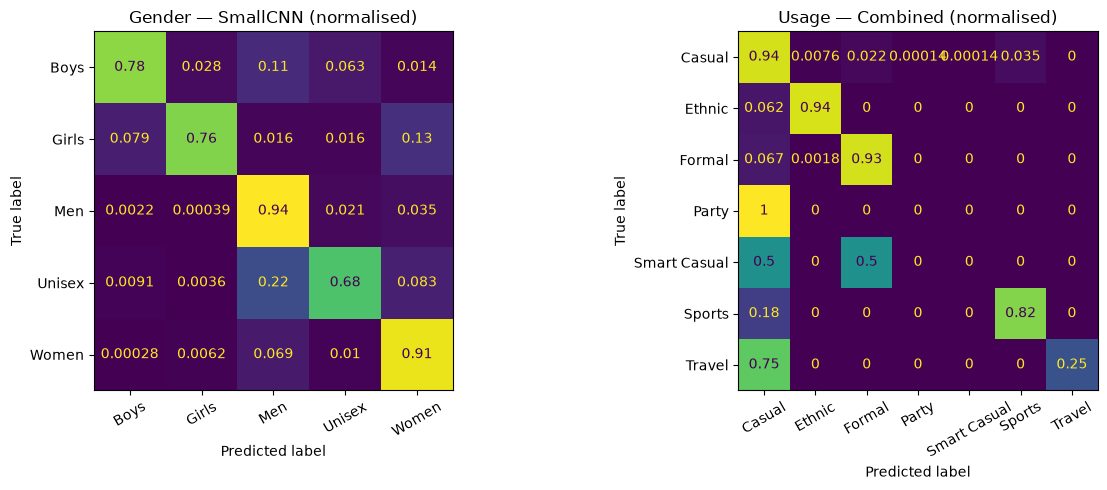


Gender classification report:
              precision    recall  f1-score   support

        Boys       0.81      0.78      0.79       143
       Girls       0.76      0.76      0.76       126
         Men       0.93      0.94      0.93      5092
      Unisex       0.71      0.68      0.69       552
       Women       0.93      0.91      0.92      3526

    accuracy                           0.91      9439
   macro avg       0.83      0.82      0.82      9439
weighted avg       0.91      0.91      0.91      9439


Usage classification report:
              precision    recall  f1-score   support

      Casual       0.96      0.94      0.95      7254
      Ethnic       0.91      0.94      0.92       611
      Formal       0.76      0.93      0.84       564
       Party       0.00      0.00      0.00         4
Smart Casual       0.00      0.00      0.00        12
      Sports       0.76      0.82      0.79       990
      Travel       1.00      0.25      0.40         4

    accuracy    

In [36]:
# ── Confusion matrices for the best FROM-SCRATCH model ────────────────────────
# NOTE: ResNet18 is ImageNet-pretrained (Section 8/9.4). The assignment spec
# requires the submitted/final model to be fully trained from scratch, and
# only allows pretrained models "for comparison" — so it is intentionally
# excluded from the candidate pool below, even if it happens to score highest.
# It still appears in the results table/bar chart above for comparison.
# Combined (B) and DualHead (C) remain in the candidate pool purely so the
# "best" selection can confirm, empirically, that separate classifiers win —
# see Section 4.2 for the full justification.
def get_preds(model, loader):
    model.eval(); p, a = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            p.extend(model(*inputs).argmax(1).cpu().numpy())
            a.extend(labels.cpu().numpy())
    return np.array(p), np.array(a)

def soft_vote_preds(cnn_model, logreg_model, loader, meta):
    cnn_probs    = get_cnn_probs(cnn_model, loader)
    logreg_probs = logreg_model.predict_proba(meta)
    return (0.5 * cnn_probs + 0.5 * logreg_probs).argmax(1)

g_pred_cnn, g_true_cnn = get_preds(gender_model, val_loader_gender)
u_pred_cnn, u_true_cnn = get_preds(usage_model,  val_loader_usage)

g_pred_gated, g_true_gated = get_preds(gender_gated_model, val_loader_gender)
u_pred_gated, u_true_gated = get_preds(usage_gated_model,  val_loader_usage)

g_pred_softvote = soft_vote_preds(gender_model, logreg_gender, val_loader_gender, meta_val)
u_pred_softvote = soft_vote_preds(usage_model,  logreg_usage,  val_loader_usage,  meta_val)

gender_predictions = {
    'SmallCNN':    (g_pred_cnn, g_true_cnn),
    'GatedFusion': (g_pred_gated, g_true_gated),
    'SoftVoting':  (g_pred_softvote, y_gender_val),
    'Combined':    (pred_gender_B, true_gender_B),
    'DualHead':    (pg_dual, ag_dual),
}
usage_predictions = {
    'SmallCNN':    (u_pred_cnn, u_true_cnn),
    'GatedFusion': (u_pred_gated, u_true_gated),
    'SoftVoting':  (u_pred_softvote, y_usage_val),
    'Combined':    (pred_usage_B, true_usage_B),
    'DualHead':    (pu_dual, au_dual),
}

candidate_gender_f1 = {'SmallCNN': f1_g_cnn, 'GatedFusion': f1_g_gated, 'SoftVoting': f1_g_softvote,
                        'Combined': f1_g_combined, 'DualHead': f1_g_dual}
candidate_usage_f1  = {'SmallCNN': f1_u_cnn, 'GatedFusion': f1_u_gated, 'SoftVoting': f1_u_softvote,
                        'Combined': f1_u_combined, 'DualHead': f1_u_dual}

best_gender_name = max(candidate_gender_f1, key=candidate_gender_f1.get)
best_gender_f1   = candidate_gender_f1[best_gender_name]
best_usage_name  = max(candidate_usage_f1, key=candidate_usage_f1.get)
best_usage_f1    = candidate_usage_f1[best_usage_name]

print(f'Best gender model (from-scratch only): {best_gender_name} (val_f1={best_gender_f1:.4f})')
print(f'Best usage model  (from-scratch only): {best_usage_name}  (val_f1={best_usage_f1:.4f})')
print(f'[Reference — pretrained, not eligible for selection] '
      f'ResNet18 gender val_f1={f1_g_resnet:.4f}, usage val_f1={f1_u_resnet:.4f}')

g_pred, g_true = gender_predictions[best_gender_name]
u_pred, u_true = usage_predictions[best_usage_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    g_true, g_pred, display_labels=gender_enc.classes_,
    ax=axes[0], xticks_rotation=30, colorbar=False, normalize='true')
axes[0].set_title(f'Gender — {best_gender_name} (normalised)')

ConfusionMatrixDisplay.from_predictions(
    u_true, u_pred, display_labels=usage_enc.classes_,
    ax=axes[1], xticks_rotation=30, colorbar=False, normalize='true')
axes[1].set_title(f'Usage — {best_usage_name} (normalised)')

plt.tight_layout()
plt.show()

print('\nGender classification report:')
print(classification_report(g_true, g_pred, target_names=gender_enc.classes_, zero_division=0))
print('\nUsage classification report:')
print(classification_report(u_true, u_pred, target_names=usage_enc.classes_,  zero_division=0))


## 13. Test-set prediction (submission)

In [37]:
# Load the test prediction template
pred_df = pd.read_csv(TEST_PRED_CSV)
pred_df['id'] = pred_df['id'].astype(str).str.strip()
print(pred_df.shape)
pred_df.head(3)

(5829, 5)


,id,gender,articleType,season,usage
0,52003,NaN,NaN,NaN,NaN
1,52007,NaN,NaN,NaN,NaN
2,52017,NaN,NaN,NaN,NaN


In [38]:
# ── Use the best (from-scratch-eligible) gender and usage models for submission ──
# best_gender_name / best_usage_name come from Section 12, and by construction
# can only be 'SmallCNN', 'GatedFusion', 'SoftVoting', 'Combined', or 'DualHead' —
# ResNet18 (pretrained) is excluded from selection, per the assignment's
# "fully train your own" rule.

class TestDataset(Dataset):
    """Test-set dataset — image only (no labels). Returns (image, id)."""
    def __init__(self, ids, image_dir, transform):
        self.ids       = ids
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self): return len(self.ids)

    def __getitem__(self, i):
        img_id = self.ids[i]
        path   = self.image_dir / f"{img_id}.jpg"
        with Image.open(path) as im:
            img = self.transform(im.convert('RGB'))
        return img, img_id


test_ids = pred_df['id'].tolist()
test_ds  = TestDataset(test_ids, IMAGES_TEST_DIR, eval_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))


def build_test_metadata():
    """OHE-encode test metadata, or zero-fill with a loud warning if the
    prediction template doesn't carry the metadata columns."""
    if all(c in pred_df.columns for c in META_COLS):
        return ohe.transform(pred_df[META_COLS])
    print("WARNING: metadata columns not available in test CSV — using zero "
          "metadata. This will likely hurt performance for MultiInput models; "
          "verify styles_prediction.csv actually lacks these columns before "
          "trusting this submission.")
    return np.zeros((len(pred_df), META_DIM))

test_meta = build_test_metadata()


def predict_single_target(model, encoder):
    """Inference for a MultiInputNet / GatedFusionNet (image+metadata -> one head) model."""
    model.eval(); results = {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set'):
            bs   = imgs.size(0)
            meta = torch.tensor(test_meta[idx:idx+bs], dtype=torch.float32).to(DEVICE)
            logits = model(imgs.to(DEVICE), meta)
            preds  = logits.argmax(1).cpu().numpy()
            for img_id, p in zip(ids, preds):
                results[img_id] = encoder.inverse_transform([p])[0]
            idx += bs
    return results


def predict_softvote(cnn_model, logreg_model, encoder):
    """Soft-vote inference: unweighted 50/50 average of CNN softmax and
    LogReg predict_proba, then argmax."""
    cnn_model.eval(); results = {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set (soft-vote)'):
            bs         = imgs.size(0)
            meta_batch = test_meta[idx:idx+bs]
            meta_t     = torch.tensor(meta_batch, dtype=torch.float32).to(DEVICE)
            cnn_probs    = torch.softmax(cnn_model(imgs.to(DEVICE), meta_t), dim=1).cpu().numpy()
            logreg_probs = logreg_model.predict_proba(meta_batch)
            preds        = (0.5 * cnn_probs + 0.5 * logreg_probs).argmax(1)
            for img_id, p in zip(ids, preds):
                results[img_id] = encoder.inverse_transform([p])[0]
            idx += bs
    return results


def predict_dual_head(model):
    """Inference for DualHeadNet — returns (gender_results, usage_results)."""
    model.eval(); g_results, u_results = {}, {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set (dual head)'):
            bs   = imgs.size(0)
            meta = torch.tensor(test_meta[idx:idx+bs], dtype=torch.float32).to(DEVICE)
            g_logit, u_logit = model(imgs.to(DEVICE), meta)
            g_preds = g_logit.argmax(1).cpu().numpy()
            u_preds = u_logit.argmax(1).cpu().numpy()
            for img_id, g, u in zip(ids, g_preds, u_preds):
                g_results[img_id] = gender_enc.inverse_transform([g])[0]
                u_results[img_id] = usage_enc.inverse_transform([u])[0]
            idx += bs
    return g_results, u_results


def predict_combined(model):
    """Inference for the combined-label model — splits the joint class
    back into (gender_results, usage_results)."""
    model.eval(); g_results, u_results = {}, {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set (combined)'):
            bs   = imgs.size(0)
            meta = torch.tensor(test_meta[idx:idx+bs], dtype=torch.float32).to(DEVICE)
            logits  = model(imgs.to(DEVICE), meta)
            preds   = logits.argmax(1).cpu().numpy()
            decoded = gender_usage_enc.inverse_transform(preds)
            for img_id, c in zip(ids, decoded):
                g, u = c.split('__')
                g_results[img_id] = g
                u_results[img_id] = u
            idx += bs
    return g_results, u_results


# ── Only run inference for approaches that actually won, avoiding wasted passes ──
if best_gender_name == 'DualHead' or best_usage_name == 'DualHead':
    g_from_dual, u_from_dual = predict_dual_head(dual_model)
if best_gender_name == 'Combined' or best_usage_name == 'Combined':
    g_from_combined, u_from_combined = predict_combined(combined_model)

gender_source = {
    'SmallCNN':    lambda: predict_single_target(gender_model, gender_enc),
    'GatedFusion': lambda: predict_single_target(gender_gated_model, gender_enc),
    'SoftVoting':  lambda: predict_softvote(gender_model, logreg_gender, gender_enc),
    'Combined':    lambda: g_from_combined,
    'DualHead':    lambda: g_from_dual,
}
usage_source = {
    'SmallCNN':    lambda: predict_single_target(usage_model, usage_enc),
    'GatedFusion': lambda: predict_single_target(usage_gated_model, usage_enc),
    'SoftVoting':  lambda: predict_softvote(usage_model, logreg_usage, usage_enc),
    'Combined':    lambda: u_from_combined,
    'DualHead':    lambda: u_from_dual,
}

gender_preds = gender_source[best_gender_name]()
usage_preds  = usage_source[best_usage_name]()

pred_df['gender'] = pred_df['id'].map(gender_preds)
pred_df['usage']  = pred_df['id'].map(usage_preds)

pred_df.to_csv(OUTPUT_DIR / 'task3_predictions.csv', index=False)
print(f"Predictions saved — {len(pred_df)} rows, "
      f"using gender={best_gender_name}, usage={best_usage_name} (from-scratch models only)")
pred_df.head()


Predicting test set (combined):   0%|          | 0/92 [00:00<?, ?it/s]

Predicting test set:   0%|          | 0/92 [00:00<?, ?it/s]

Predictions saved — 5829 rows, using gender=SmallCNN, usage=Combined (from-scratch models only)


,id,gender,articleType,season,usage
0,52003,Men,NaN,NaN,Casual
1,52007,Women,NaN,NaN,Casual
2,52017,Women,NaN,NaN,Casual
3,52021,Women,NaN,NaN,Casual
4,52023,Men,NaN,NaN,Casual


## 14. Save models & encoders

In [39]:
models_to_save = {
    'gender_multiinput_smallcnn.pt':    gender_model,
    'gender_multiinput_resnet18.pt':    gender_resnet_model,
    'gender_gatedfusion.pt':            gender_gated_model,
    'usage_multiinput_smallcnn.pt':     usage_model,
    'usage_multiinput_resnet18.pt':     usage_resnet_model,
    'usage_gatedfusion.pt':             usage_gated_model,
    'combined_gender_usage_smallcnn.pt': combined_model,
    'dual_head_gender_usage.pt':         dual_model,
}

for fname, model in models_to_save.items():
    torch.save(model.state_dict(), OUTPUT_DIR / fname)
    print(f'Saved {fname}')

print(f'\nAll files in {OUTPUT_DIR}:')
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:<45} {size_mb:.1f} MB')


Saved gender_multiinput_smallcnn.pt
Saved gender_multiinput_resnet18.pt
Saved gender_gatedfusion.pt
Saved usage_multiinput_smallcnn.pt
Saved usage_multiinput_resnet18.pt
Saved usage_gatedfusion.pt
Saved combined_gender_usage_smallcnn.pt
Saved dual_head_gender_usage.pt

All files in ../outputs/task3_models:
  baselines                                     0.0 MB
  combined_gender_usage_smallcnn.pt             5.5 MB
  dual_head_gender_usage.pt                     5.4 MB
  gender_encoder.joblib                         0.0 MB
  gender_gatedfusion.pt                         5.5 MB
  gender_multiinput_resnet18.pt                 45.4 MB
  gender_multiinput_smallcnn.pt                 5.4 MB
  gender_usage_encoder.joblib                   0.0 MB
  image_only                                    0.0 MB
  ohe_metadata.joblib                           0.0 MB
  task3_predictions.csv                         0.1 MB
  usage_encoder.joblib                          0.0 MB
  usage_gatedfusion.pt         

### 14.1 Artefacts for the chained pipeline notebook

**MODIFY - new subsection, nothing above is changed.** `COSC2753_A2_Pipeline.ipynb` needs, per
target: the label encoder, the fitted metadata one-hot encoder (both already written in
Section 7), an image-only model for Stage 1 (the test set has no metadata) and a multi-input
model for Stage 2. The cell below re-saves the two model kinds with the metadata needed to
rebuild them - the encoder class chosen in 9.2.4, its output width, the metadata width and
the class list.

In [40]:
# MODIFY: new. Re-saves the four Task 3 models the pipeline notebook consumes, this time as
# self-describing checkpoints. The plain `state_dict()` files written above cannot be loaded
# without knowing which encoder was picked, how wide the metadata vector is and how many
# classes there are -- all of which vary per run, since Section 9.2.4 selects the best
# from-scratch encoder empirically. Filenames are the ones the pipeline already looks for.
#
# Nothing is retrained here: these are the objects Sections 9.2/9.3/9.5 already produced.
manifest = {
    'image_size_hw': [int(IMG_HEIGHT), int(IMG_WIDTH)],
    'normalization_mean': list(NORM_MEAN),
    'normalization_std': list(NORM_STD),
    'metadata_features': list(META_COLS),
    'metadata_dim': int(META_DIM),
    'targets': {},
}

for tag, target_col, imgonly, imgonly_name, multi, enc, n_cls in [
    ('gender', 'gender', best_gender_imgonly['model'], best_gender_imgonly_name,
     gender_model, gender_enc, N_GENDER),
    ('usage', 'usage', best_usage_imgonly['model'], best_usage_imgonly_name,
     usage_model, usage_enc, N_USAGE),
]:
    torch.save({
        'model_state_dict': imgonly.state_dict(),
        'wrapper': 'ImageOnlyNet',
        'image_encoder': type(imgonly.image).__name__,
        'out_dim': int(imgonly.image.out_dim),
        'n_classes': int(n_cls),
        'classes': enc.classes_.tolist(),
        'selected_as': imgonly_name,
        'pretrained': False,
    }, OUTPUT_DIR / f'{tag}_imageonly_smallcnn.pt')

    torch.save({
        'model_state_dict': multi.state_dict(),
        'wrapper': 'MultiInputNet',
        'image_encoder': type(multi.image).__name__,
        'out_dim': int(multi.image.out_dim),
        'metadata_dim': int(META_DIM),
        'metadata_features': list(META_COLS),
        'n_classes': int(n_cls),
        'classes': enc.classes_.tolist(),
        'target_column': target_col,
        'pretrained': False,
    }, OUTPUT_DIR / f'{tag}_multiinput_smallcnn.pt')

    manifest['targets'][tag] = {
        'target_column': target_col,
        'classes': enc.classes_.tolist(),
        'image_only_encoder': type(imgonly.image).__name__,
        'image_only_selected_as': imgonly_name,
        'multi_input_encoder': type(multi.image).__name__,
        'files': {
            'label_encoder': f'{tag}_encoder.joblib',
            'metadata_one_hot': 'ohe_metadata.joblib',
            'image_only': f'{tag}_imageonly_smallcnn.pt',
            'multi_input': f'{tag}_multiinput_smallcnn.pt',
        },
    }

(OUTPUT_DIR / 'task3_artifacts.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')

print('Artefacts for the pipeline notebook:')
for name in ['gender_imageonly_smallcnn.pt', 'usage_imageonly_smallcnn.pt',
             'gender_multiinput_smallcnn.pt', 'usage_multiinput_smallcnn.pt',
             'gender_encoder.joblib', 'usage_encoder.joblib', 'ohe_metadata.joblib',
             'task3_artifacts.json']:
    p = OUTPUT_DIR / name
    size = f"{p.stat().st_size / 1024:8.1f} KB" if p.exists() else ""
    print(f"  [{'OK' if p.exists() else 'MISSING':>7}] {name:34s} {size}")

print(f"\nNote: the *_imageonly_smallcnn.pt names are kept for compatibility with the pipeline "
      f"notebook; the encoder actually inside them is whichever from-scratch encoder won in "
      f"Section 9.2.4 -- gender: {manifest['targets']['gender']['image_only_encoder']}, "
      f"usage: {manifest['targets']['usage']['image_only_encoder']}. The pipeline reads the "
      f"class name from the checkpoint rather than assuming one.")

Artefacts for the pipeline notebook:
  [     OK] gender_imageonly_smallcnn.pt         5115.0 KB
  [     OK] usage_imageonly_smallcnn.pt          5116.9 KB
  [     OK] gender_multiinput_smallcnn.pt        5309.2 KB
  [     OK] usage_multiinput_smallcnn.pt         5311.2 KB
  [     OK] gender_encoder.joblib                   0.5 KB
  [     OK] usage_encoder.joblib                    0.5 KB
  [     OK] ohe_metadata.joblib                     4.4 KB
  [     OK] task3_artifacts.json                    1.6 KB

Note: the *_imageonly_smallcnn.pt names are kept for compatibility with the pipeline notebook; the encoder actually inside them is whichever from-scratch encoder won in Section 9.2.4 -- gender: SEResidualImageEncoder, usage: SEResidualImageEncoder. The pipeline reads the class name from the checkpoint rather than assuming one.
